# Práctica Tema 1: Construcción de una red de neuronas

### Librerías

In [1]:
import tensorflow as tf
import pandas as pd
import matplotlib.pyplot as plt
import time
import numpy as np
import random
 
print("Tensorflow version: " + tf.__version__)
    
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


2026-03-24 18:50:19.466882: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-24 18:50:19.511386: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-24 18:50:20.550380: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Tensorflow version: 2.20.0


### Funciones auxiliares de visualización

In [2]:
def display_loss_curve(history):
    plt.figure(figsize=(8, 5))

    plt.plot(history.history["loss"], label="train loss")
    plt.plot(history.history["val_loss"], label="test loss")

    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("Model Loss")
    plt.legend(loc="upper right")

    plt.tight_layout()
    plt.show()

def display_error_curve(history):
    plt.figure(figsize=(8, 5))

    train_error = [1 - acc for acc in history.history["categorical_accuracy"]]
    test_error = [1 - acc for acc in history.history["val_categorical_accuracy"]]

    plt.plot(train_error, label="train error")
    plt.plot(test_error, label="test error")

    plt.xlabel("Epochs")
    plt.ylabel("Error")
    plt.title("Model Error")
    plt.ylim(0, 1)
    plt.legend(loc="upper right")

    plt.tight_layout()
    plt.show()

def display_results(history, start_time, end_time, irreducible_error):
    """Muestra métricas de error, curvas de loss y curvas de error."""
    results = pd.DataFrame(history.history)

    error_training = (1 - results.categorical_accuracy.values[-1:][0])*100
    error_test = (1 - results.val_categorical_accuracy.values[-1:][0])*100
    error_bias = error_training - irreducible_error*100
    error_variance = error_test - error_training

    print ("Error training: ", round(error_training,1), "%")
    print ("Error development test: ", round(error_test, 1), "%")
    print ("Error bias: ", round(error_bias, 1), "%")
    print ("Error variance: ", round(error_variance, 1), "%")
    print ("Time: ", round((end_time - start_time)),"seconds")
    accuracy_training = 100 - error_training
    accuracy_test     = 100 - error_test
 
    print("Accuracy training:    ", round(accuracy_training, 1), "%")
    print("Accuracy dev test:    ", round(accuracy_test, 1), "%")

    display_loss_curve(history)
    display_error_curve(history)

def display_accuracy_curve(history):
    plt.figure(figsize=(8, 5))

    plt.plot(history.history["categorical_accuracy"], label="train accuracy")
    plt.plot(history.history["val_categorical_accuracy"], label="test accuracy")

    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.title("Model Accuracy")
    plt.ylim(0, 1)
    plt.legend(loc="lower right")

    plt.tight_layout()
    plt.show()

### Carga de datos y partición (80% train / 10% dev / 10% test)

In [3]:
ATT_FILE =   "FootballPlayerPreparedCleanAttributes.csv"
LABEL_FILE = "FootballPlayerOneHotEncodedClasses.csv"

attributes = pd.read_csv(ATT_FILE)
label =      pd.read_csv(LABEL_FILE)

TRAIN_RATIO = 0.8
DEV_RATIO   = 0.1

n_instances = attributes.shape[0]
n_train = int(n_instances*TRAIN_RATIO)
n_dev = int(n_instances * DEV_RATIO)

x_train = attributes.values[:n_train]
t_train = label.values[:n_train]
x_dev   = attributes.values[n_train : n_train + n_dev]
t_dev   = label.values[n_train : n_train + n_dev]
x_test  = attributes.values[n_train + n_dev:]
t_test  = label.values[n_train + n_dev:]

INPUTS =  x_train.shape[1]
OUTPUTS = t_train.shape[1]

print("Inputs:", INPUTS)
print("Outputs:", OUTPUTS)
print("Train instances:", x_train.shape[0])
print("Dev instances:  ", x_dev.shape[0])
print("Test instances: ", x_test.shape[0])

Inputs: 22
Outputs: 4
Train instances: 12907
Dev instances:   1613
Test instances:  1614


## Paso 1: Modelo más simple posible

In [4]:
IRREDUCIBLE_ERROR = 0.10 
model_1 = tf.keras.Sequential()
model_1.add(tf.keras.layers.InputLayer(shape=(INPUTS,)))
model_1.add(tf.keras.layers.Dense(OUTPUTS, activation="softmax"))
 
model_1.compile(
    loss="categorical_crossentropy",
    optimizer="sgd",
    metrics=["categorical_accuracy"]
)
 
model_1.summary()

I0000 00:00:1774374623.090023  904127 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2148 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 4)              │            92 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 92 (368.00 B)

 Trainable params: 92 (368.00 B)

 Non-trainable params: 0 (0.00 B)

In [5]:
start_time_1 = time.perf_counter()
 
history_1 = model_1.fit(
    x_train, t_train,
    epochs=100,
    verbose=0,
    validation_data=(x_dev, t_dev)
)
 
end_time_1 = time.perf_counter()

2026-03-24 18:50:23.853450: I external/local_xla/xla/service/service.cc:163] XLA service 0x753204016900 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-03-24 18:50:23.853463: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 3050 Laptop GPU, Compute Capability 8.6
2026-03-24 18:50:23.866585: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-03-24 18:50:23.890423: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91900
I0000 00:00:1774374624.362987  904299 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


Error training:  31.5 %
Error development test:  31.7 %
Error bias:  21.5 %
Error variance:  0.1 %
Time:  41 seconds
Accuracy training:     68.5 %
Accuracy dev test:     68.3 %


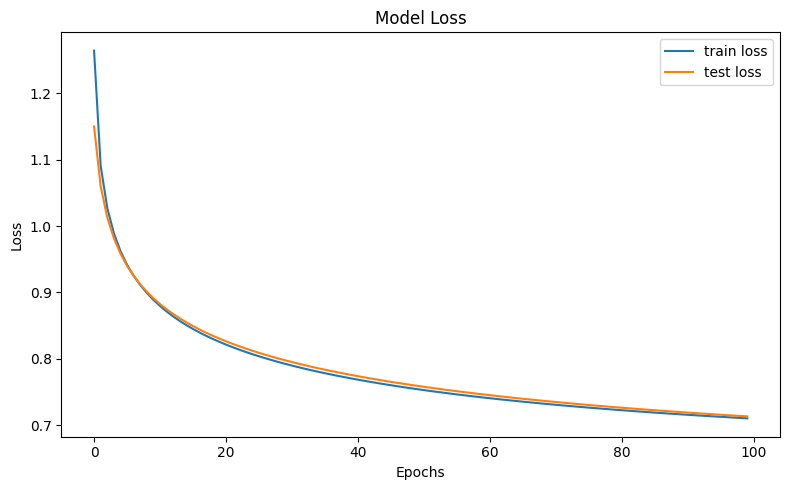

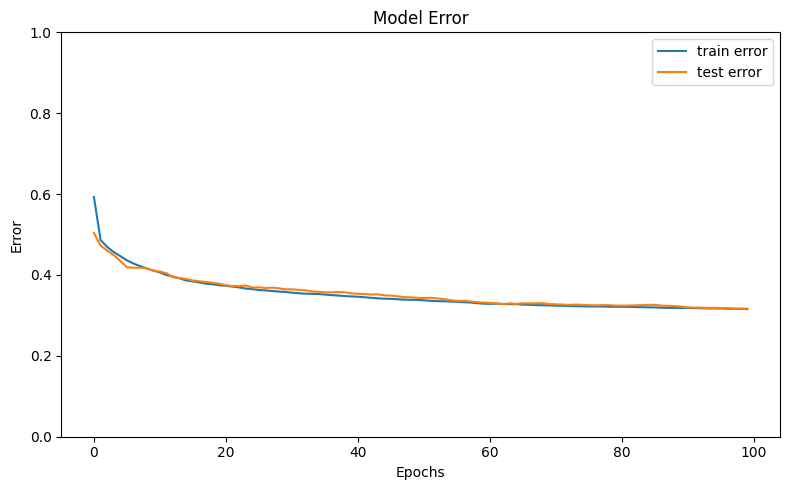

In [6]:
display_results(history_1, start_time_1, end_time_1, IRREDUCIBLE_ERROR)

## Paso 2: añadir capas ocultas con ReLU

In [7]:
model_2 = tf.keras.Sequential()
model_2.add(tf.keras.layers.InputLayer(shape=(INPUTS,)))
model_2.add(tf.keras.layers.Dense(64, activation="relu"))
model_2.add(tf.keras.layers.Dense(64, activation="relu"))
model_2.add(tf.keras.layers.Dense(OUTPUTS, activation="softmax"))

model_2.compile(
    loss="categorical_crossentropy",
    optimizer="sgd",
    metrics=["categorical_accuracy"]
)
 
model_2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 64)             │         1,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,892 (23.02 KB)

 Trainable params: 5,892 (23.02 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
start_time_2 = time.perf_counter()
 
history_2 = model_2.fit(
    x_train, t_train,
    epochs=100,
    verbose=0,
    validation_data=(x_dev, t_dev)
)
 
end_time_2 = time.perf_counter()

Error training:  12.7 %
Error development test:  13.0 %
Error bias:  2.7 %
Error variance:  0.3 %
Time:  44 seconds
Accuracy training:     87.3 %
Accuracy dev test:     87.0 %


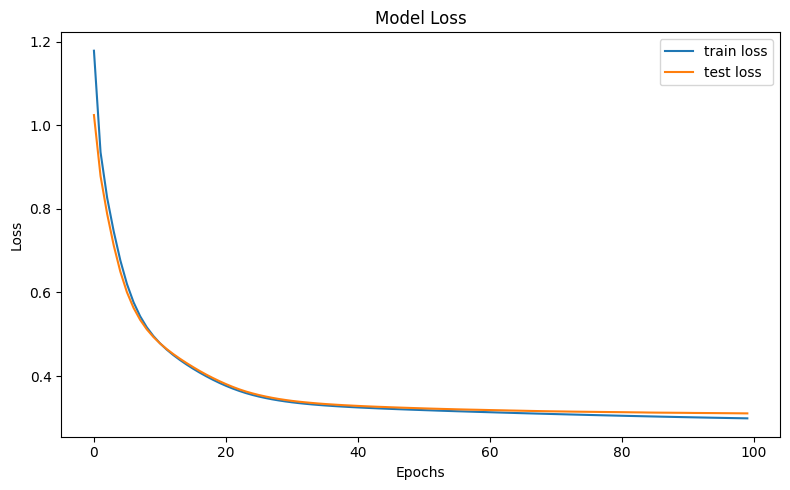

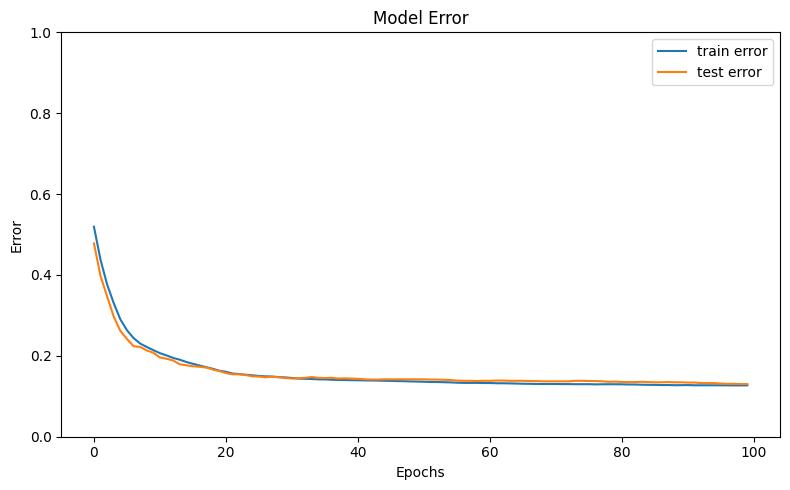

In [9]:
display_results(history_2, start_time_2, end_time_2, IRREDUCIBLE_ERROR)

## Paso 3: Pasar de 100 epochs a 300 epochs

In [10]:
model_3 = tf.keras.Sequential()
model_3.add(tf.keras.layers.InputLayer(shape=(INPUTS,)))
model_3.add(tf.keras.layers.Dense(64, activation="relu"))
model_3.add(tf.keras.layers.Dense(64, activation="relu"))
model_3.add(tf.keras.layers.Dense(OUTPUTS, activation="softmax"))

model_3.compile(
    loss="categorical_crossentropy",
    optimizer="sgd",
    metrics=["categorical_accuracy"]
)
 
model_3.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 64)             │         1,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,892 (23.02 KB)

 Trainable params: 5,892 (23.02 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
start_time_3 = time.perf_counter()
 
history_3 = model_3.fit(
    x_train, t_train,
    epochs=300,
    verbose=0,
    validation_data=(x_dev, t_dev)
)
 
end_time_3 = time.perf_counter()

Error training:  11.0 %
Error development test:  12.5 %
Error bias:  1.0 %
Error variance:  1.5 %
Time:  129 seconds
Accuracy training:     89.0 %
Accuracy dev test:     87.5 %


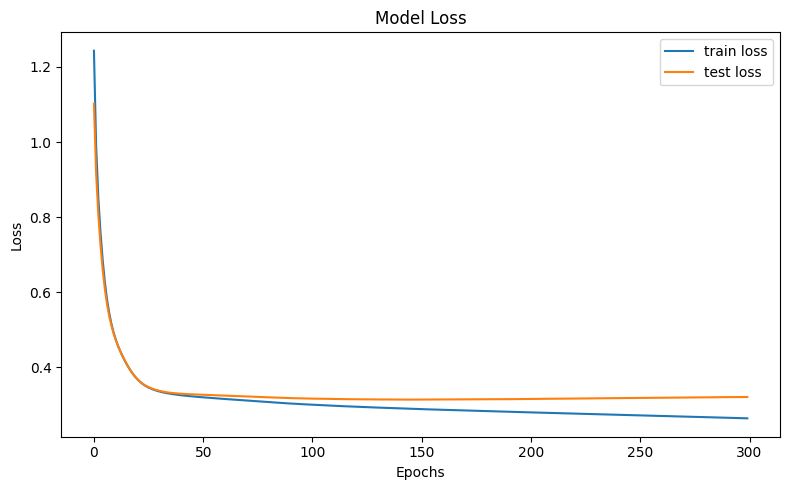

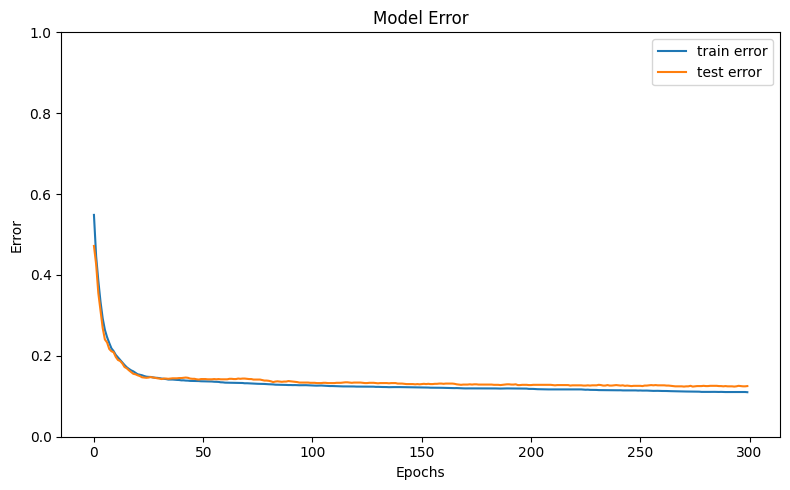

In [12]:
display_results(history_3, start_time_3, end_time_3, IRREDUCIBLE_ERROR)

## Paso 4: Añadir regularización L2 muy baja (0.001)

In [13]:
REGULARIZATION_FACTOR_4 = 0.001
REGULARIZER_4 = tf.keras.regularizers.L2(REGULARIZATION_FACTOR_4)

model_4 = tf.keras.Sequential()
model_4.add(tf.keras.layers.InputLayer(shape=(INPUTS,)))
model_4.add(tf.keras.layers.Dense(64, activation="relu", kernel_regularizer=REGULARIZER_4))
model_4.add(tf.keras.layers.Dense(64, activation="relu", kernel_regularizer=REGULARIZER_4))
model_4.add(tf.keras.layers.Dense(OUTPUTS, activation="softmax", kernel_regularizer=REGULARIZER_4))

model_4.compile(
    loss="categorical_crossentropy",
    optimizer="sgd",
    metrics=["categorical_accuracy"]
)
 
model_4.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 64)             │         1,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,892 (23.02 KB)

 Trainable params: 5,892 (23.02 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
start_time_4 = time.perf_counter()
 
history_4 = model_4.fit(
    x_train, t_train,
    epochs=300,
    verbose=0,
    validation_data=(x_dev, t_dev)
)
 
end_time_4 = time.perf_counter()

Error training:  12.7 %
Error development test:  12.0 %
Error bias:  2.7 %
Error variance:  -0.6 %
Time:  125 seconds
Accuracy training:     87.3 %
Accuracy dev test:     88.0 %


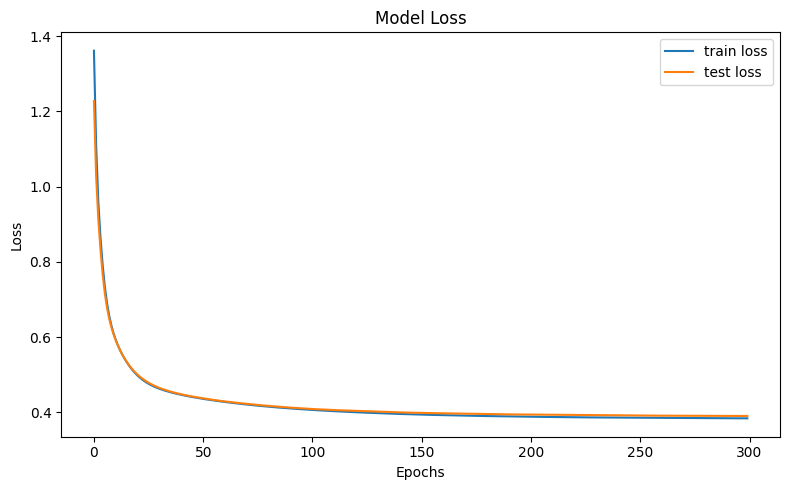

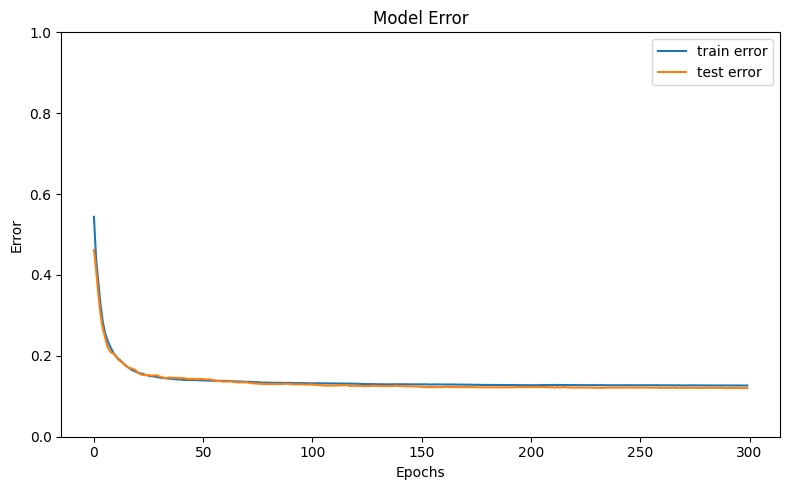

In [15]:
display_results(history_4, start_time_4, end_time_4, IRREDUCIBLE_ERROR)

## Paso 5: Bajar regularización L2 (0.0001)

In [16]:
REGULARIZATION_FACTOR_5 = 0.0001
REGULARIZER_5 = tf.keras.regularizers.L2(REGULARIZATION_FACTOR_5)

model_5 = tf.keras.Sequential()
model_5.add(tf.keras.layers.InputLayer(shape=(INPUTS,)))
model_5.add(tf.keras.layers.Dense(64, activation="relu", kernel_regularizer=REGULARIZER_5))
model_5.add(tf.keras.layers.Dense(64, activation="relu", kernel_regularizer=REGULARIZER_5))
model_5.add(tf.keras.layers.Dense(OUTPUTS, activation="softmax", kernel_regularizer=REGULARIZER_5))

model_5.compile(
    loss="categorical_crossentropy",
    optimizer="sgd",
    metrics=["categorical_accuracy"]
)
 
model_5.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 64)             │         1,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,892 (23.02 KB)

 Trainable params: 5,892 (23.02 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
start_time_5 = time.perf_counter()
 
history_5 = model_5.fit(
    x_train, t_train,
    epochs=300,
    verbose=0,
    validation_data=(x_dev, t_dev)
)
 
end_time_5 = time.perf_counter()

Error training:  11.3 %
Error development test:  12.2 %
Error bias:  1.3 %
Error variance:  0.9 %
Time:  126 seconds
Accuracy training:     88.7 %
Accuracy dev test:     87.8 %


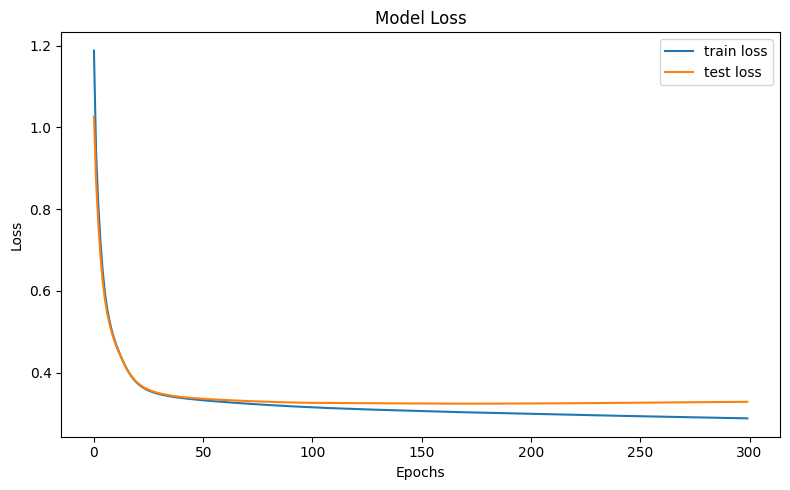

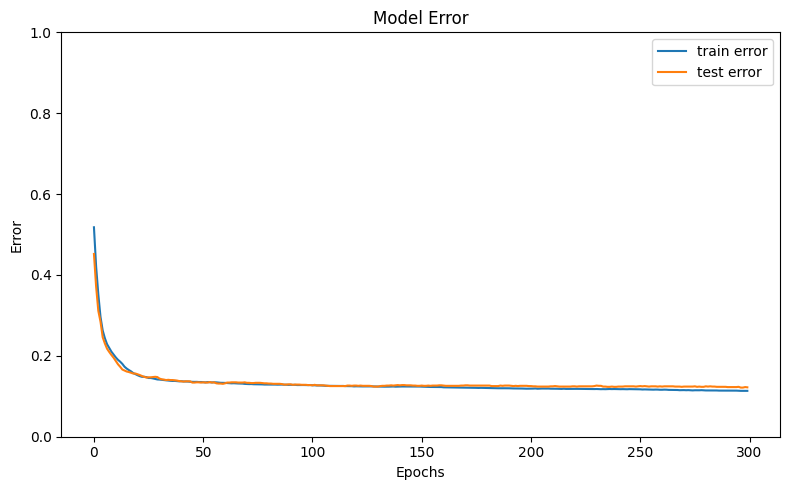

In [18]:
display_results(history_5, start_time_5, end_time_5, IRREDUCIBLE_ERROR)

## Paso 6: Subir ligeramente la regularización L2 (0.0003)

In [19]:
REGULARIZATION_FACTOR_6 = 0.0003
REGULARIZER_6 = tf.keras.regularizers.L2(REGULARIZATION_FACTOR_6)

model_6 = tf.keras.Sequential()
model_6.add(tf.keras.layers.InputLayer(shape=(INPUTS,)))
model_6.add(tf.keras.layers.Dense(64, activation="relu", kernel_regularizer=REGULARIZER_6))
model_6.add(tf.keras.layers.Dense(64, activation="relu", kernel_regularizer=REGULARIZER_6))
model_6.add(tf.keras.layers.Dense(OUTPUTS, activation="softmax", kernel_regularizer=REGULARIZER_6))

model_6.compile(
    loss="categorical_crossentropy",
    optimizer="sgd",
    metrics=["categorical_accuracy"]
)
 
model_6.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_13 (Dense)                │ (None, 64)             │         1,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,892 (23.02 KB)

 Trainable params: 5,892 (23.02 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
start_time_6 = time.perf_counter()
 
history_6 = model_6.fit(
    x_train, t_train,
    epochs=300,
    verbose=0,
    validation_data=(x_dev, t_dev)
)
 
end_time_6 = time.perf_counter()

Error training:  11.9 %
Error development test:  12.6 %
Error bias:  1.9 %
Error variance:  0.8 %
Time:  124 seconds
Accuracy training:     88.1 %
Accuracy dev test:     87.4 %


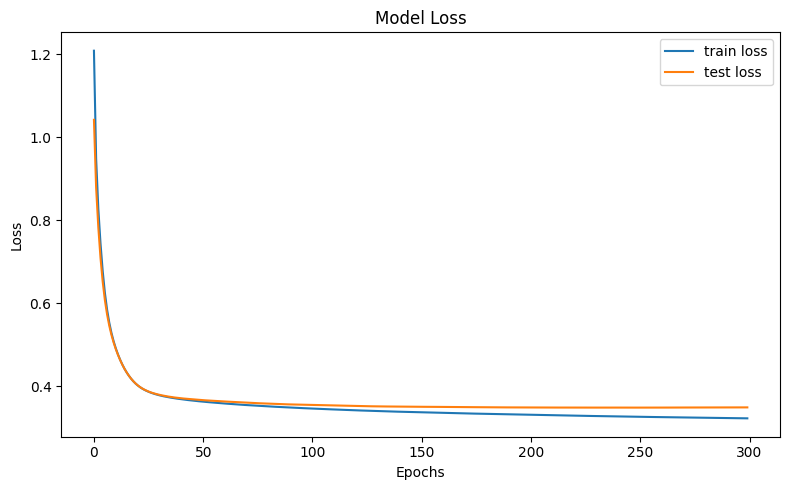

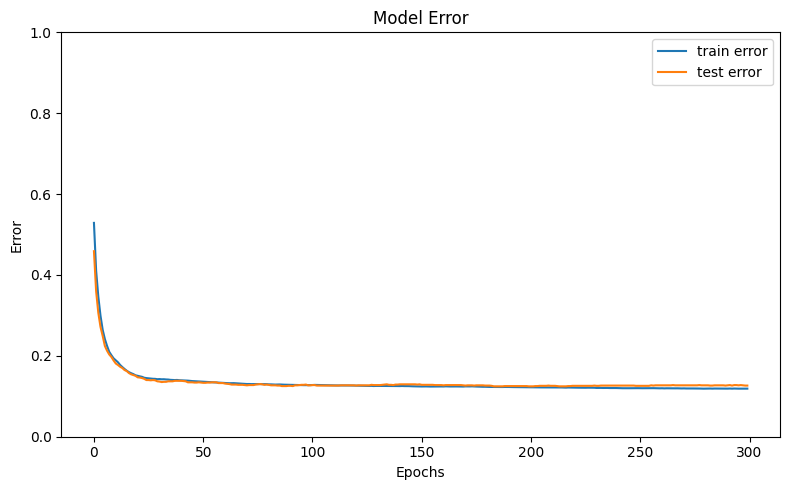

In [21]:
display_results(history_6, start_time_6, end_time_6, IRREDUCIBLE_ERROR)

## Paso 7: Quitamos regularización L2 y ponemos Dropout (0.2)

In [22]:
DROPOUT_RATE_7 = 0.2

model_7 = tf.keras.Sequential()
model_7.add(tf.keras.layers.InputLayer(shape=(INPUTS,)))
model_7.add(tf.keras.layers.Dense(64, activation="relu"))
model_7.add(tf.keras.layers.Dropout(DROPOUT_RATE_7))
model_7.add(tf.keras.layers.Dense(64, activation="relu"))
model_7.add(tf.keras.layers.Dropout(DROPOUT_RATE_7))
model_7.add(tf.keras.layers.Dense(OUTPUTS, activation="softmax"))

model_7.compile(
    loss="categorical_crossentropy",
    optimizer="sgd",
    metrics=["categorical_accuracy"]
)
 
model_7.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_16 (Dense)                │ (None, 64)             │         1,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,892 (23.02 KB)

 Trainable params: 5,892 (23.02 KB)

 Non-trainable params: 0 (0.00 B)

In [23]:
start_time_7 = time.perf_counter()
 
history_7 = model_7.fit(
    x_train, t_train,
    epochs=300,
    verbose=0,
    validation_data=(x_dev, t_dev)
)
 
end_time_7 = time.perf_counter()

Error training:  13.7 %
Error development test:  12.6 %
Error bias:  3.7 %
Error variance:  -1.0 %
Time:  131 seconds
Accuracy training:     86.3 %
Accuracy dev test:     87.4 %


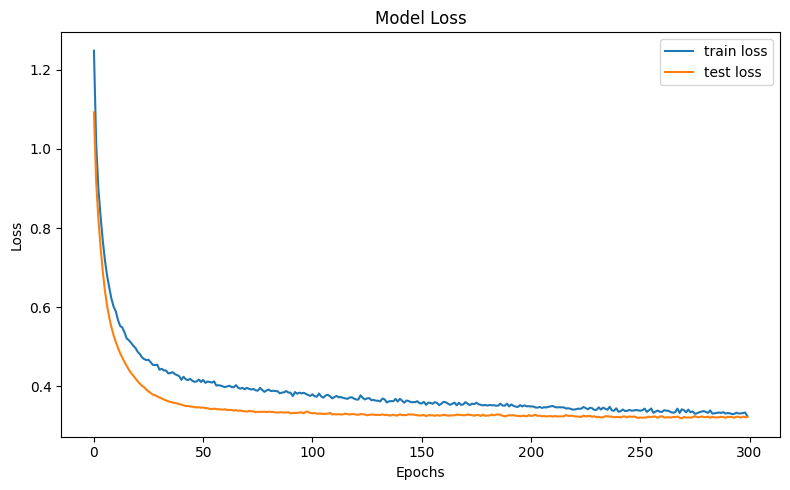

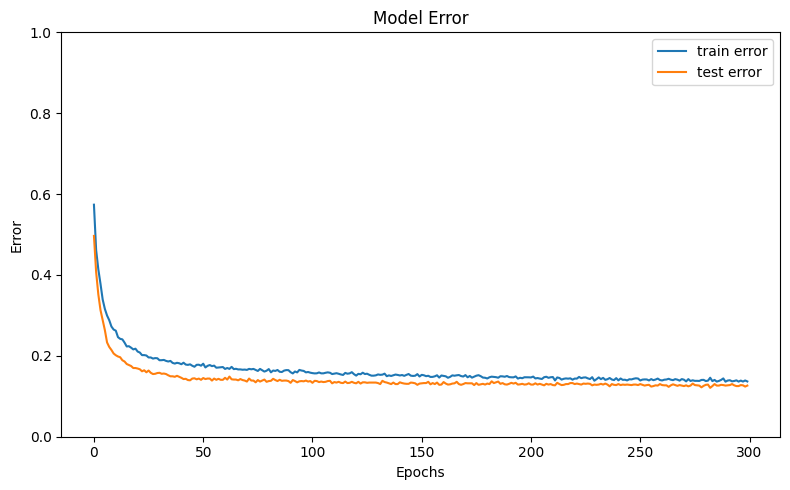

In [24]:
display_results(history_7, start_time_7, end_time_7, IRREDUCIBLE_ERROR)

## Paso 8: Volvemos al modelo sin nada y aumentamos capas y neuronas

In [25]:
model_8 = tf.keras.Sequential()
model_8.add(tf.keras.layers.InputLayer(shape=(INPUTS,)))
model_8.add(tf.keras.layers.Dense(128, activation="relu"))
model_8.add(tf.keras.layers.Dense(128, activation="relu"))
model_8.add(tf.keras.layers.Dense(64, activation="relu"))
model_8.add(tf.keras.layers.Dense(OUTPUTS, activation="softmax"))

model_8.compile(
    loss="categorical_crossentropy",
    optimizer="sgd",
    metrics=["categorical_accuracy"]
)
 
model_8.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_19 (Dense)                │ (None, 128)            │         2,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,972 (109.27 KB)

 Trainable params: 27,972 (109.27 KB)

 Non-trainable params: 0 (0.00 B)

In [26]:
start_time_8 = time.perf_counter()
 
history_8 = model_8.fit(
    x_train, t_train,
    epochs=300,
    verbose=0,
    validation_data=(x_dev, t_dev)
)
 
end_time_8 = time.perf_counter()

2026-03-24 19:02:26.164005: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-24 19:02:26.164029: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-24 19:02:26.164053: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-24 19:02:26.164072: I external/l

Error training:  7.1 %
Error development test:  14.1 %
Error bias:  -2.9 %
Error variance:  7.0 %
Time:  130 seconds
Accuracy training:     92.9 %
Accuracy dev test:     85.9 %


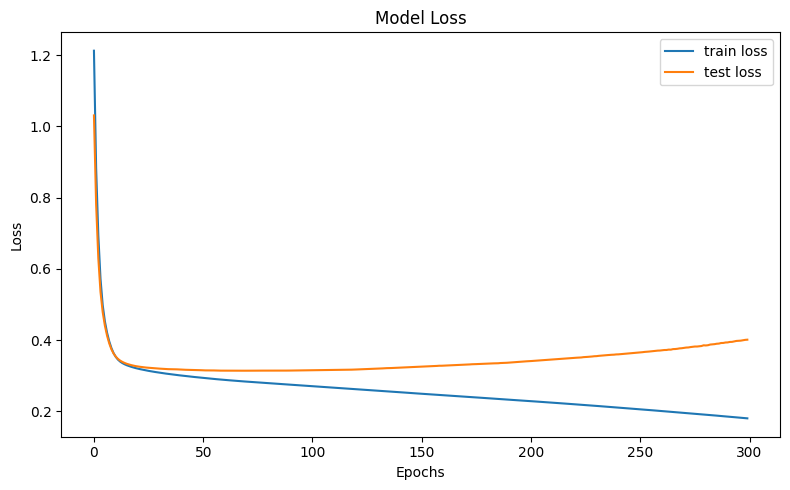

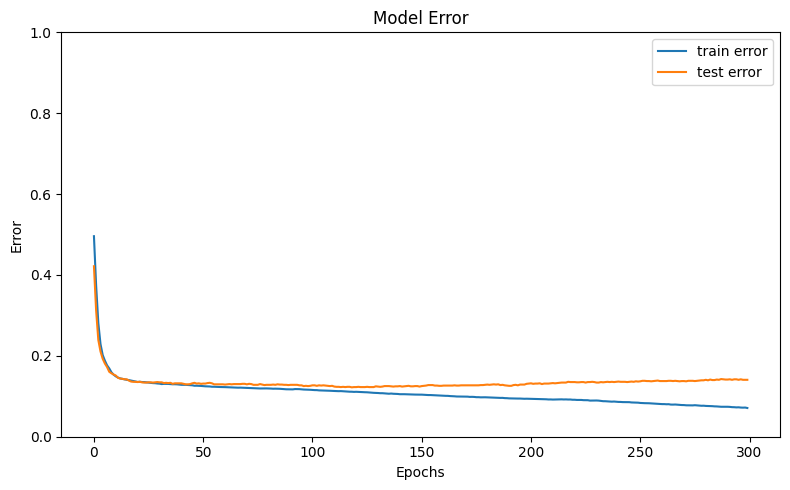

In [27]:
display_results(history_8, start_time_8, end_time_8, IRREDUCIBLE_ERROR)

## Paso 9: Volvemos a probar con dropout 0.2

In [28]:
DROPOUT_RATE_9 = 0.2

model_9 = tf.keras.Sequential()
model_9.add(tf.keras.layers.InputLayer(shape=(INPUTS,)))
model_9.add(tf.keras.layers.Dense(128, activation="relu"))
model_9.add(tf.keras.layers.Dropout(DROPOUT_RATE_9))
model_9.add(tf.keras.layers.Dense(128, activation="relu"))
model_9.add(tf.keras.layers.Dropout(DROPOUT_RATE_9))
model_9.add(tf.keras.layers.Dense(64, activation="relu"))
model_9.add(tf.keras.layers.Dropout(DROPOUT_RATE_9))
model_9.add(tf.keras.layers.Dense(OUTPUTS, activation="softmax"))

model_9.compile(
    loss="categorical_crossentropy",
    optimizer="sgd",
    metrics=["categorical_accuracy"]
)
 
model_9.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_23 (Dense)                │ (None, 128)            │         2,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,972 (109.27 KB)

 Trainable params: 27,972 (109.27 KB)

 Non-trainable params: 0 (0.00 B)

In [29]:
start_time_9 = time.perf_counter()
 
history_9 = model_9.fit(
    x_train, t_train,
    epochs=300,
    verbose=0,
    validation_data=(x_dev, t_dev)
)
 
end_time_9 = time.perf_counter()

2026-03-24 19:04:36.553111: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-24 19:04:36.553138: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-24 19:04:36.553152: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-24 19:04:36.553170: I external/l

Error training:  11.8 %
Error development test:  13.8 %
Error bias:  1.8 %
Error variance:  2.0 %
Time:  134 seconds
Accuracy training:     88.2 %
Accuracy dev test:     86.2 %


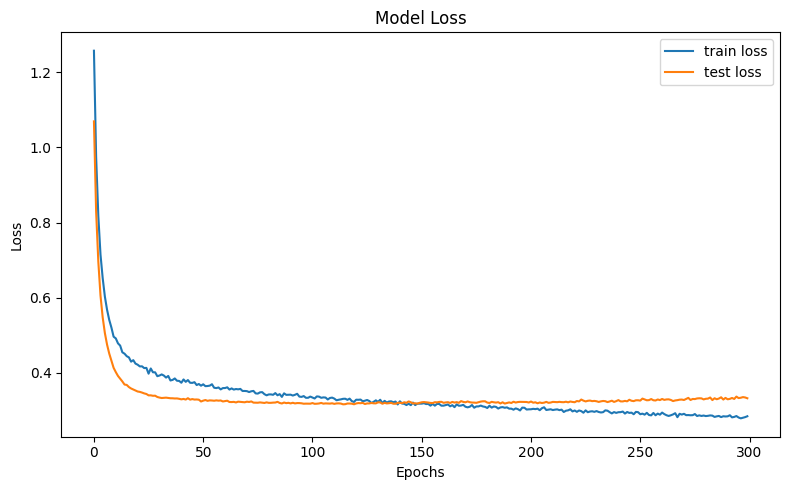

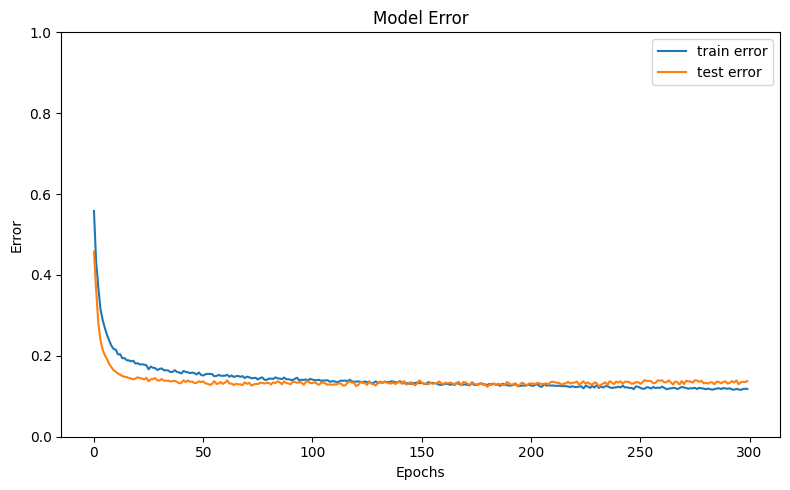

In [30]:
display_results(history_9, start_time_9, end_time_9, IRREDUCIBLE_ERROR)

## Paso 10: Ahora con dropout 0.1

In [31]:
DROPOUT_RATE_10 = 0.1

model_10 = tf.keras.Sequential()
model_10.add(tf.keras.layers.InputLayer(shape=(INPUTS,)))
model_10.add(tf.keras.layers.Dense(128, activation="relu"))
model_10.add(tf.keras.layers.Dropout(DROPOUT_RATE_10))
model_10.add(tf.keras.layers.Dense(128, activation="relu"))
model_10.add(tf.keras.layers.Dropout(DROPOUT_RATE_10))
model_10.add(tf.keras.layers.Dense(64, activation="relu"))
model_10.add(tf.keras.layers.Dropout(DROPOUT_RATE_10))
model_10.add(tf.keras.layers.Dense(OUTPUTS, activation="softmax"))

model_10.compile(
    loss="categorical_crossentropy",
    optimizer="sgd",
    metrics=["categorical_accuracy"]
)
 
model_10.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_27 (Dense)                │ (None, 128)            │         2,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,972 (109.27 KB)

 Trainable params: 27,972 (109.27 KB)

 Non-trainable params: 0 (0.00 B)

In [32]:
start_time_10 = time.perf_counter()
 
history_10 = model_10.fit(
    x_train, t_train,
    epochs=300,
    verbose=0,
    validation_data=(x_dev, t_dev)
)
 
end_time_10 = time.perf_counter()

Error training:  10.4 %
Error development test:  13.3 %
Error bias:  0.4 %
Error variance:  2.8 %
Time:  132 seconds
Accuracy training:     89.6 %
Accuracy dev test:     86.7 %


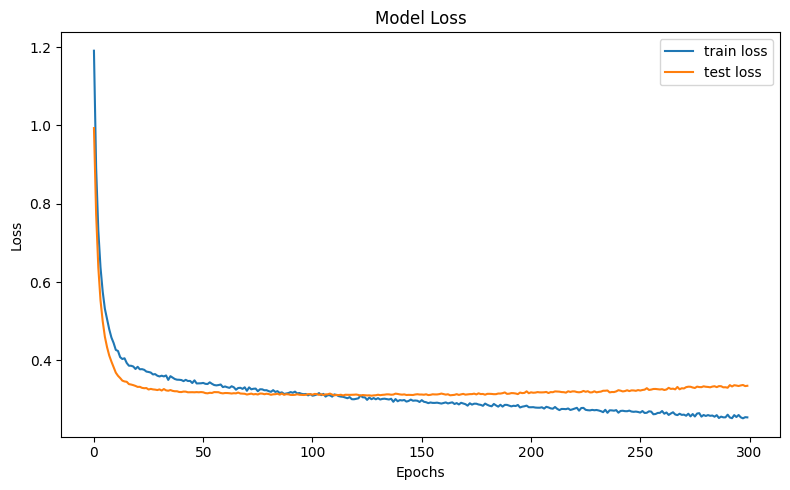

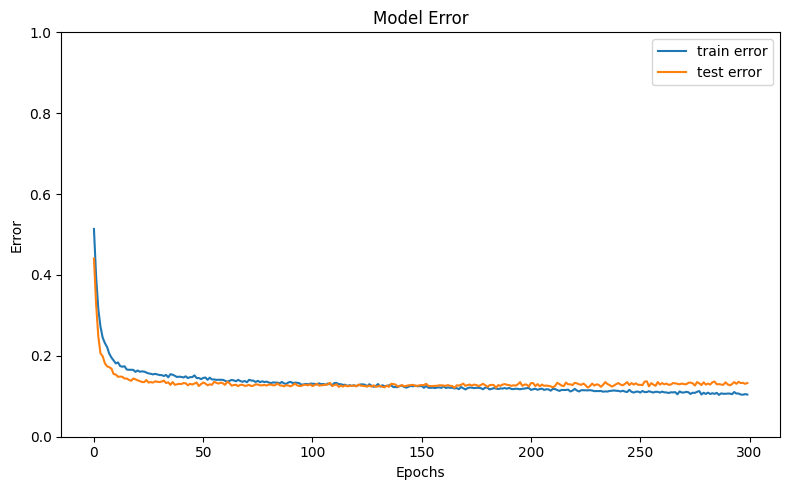

In [33]:
display_results(history_10, start_time_10, end_time_10, IRREDUCIBLE_ERROR)

## Paso 11: Reducimos neuronas

In [34]:
model_11 = tf.keras.Sequential()
model_11.add(tf.keras.layers.InputLayer(shape=(INPUTS,)))
model_11.add(tf.keras.layers.Dense(128, activation="relu"))
model_11.add(tf.keras.layers.Dense(64, activation="relu"))
model_11.add(tf.keras.layers.Dense(32, activation="relu"))
model_11.add(tf.keras.layers.Dense(OUTPUTS, activation="softmax"))

model_11.compile(
    loss="categorical_crossentropy",
    optimizer="sgd",
    metrics=["categorical_accuracy"]
)
 
model_11.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_31 (Dense)                │ (None, 128)            │         2,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,412 (52.39 KB)

 Trainable params: 13,412 (52.39 KB)

 Non-trainable params: 0 (0.00 B)

In [35]:
start_time_11 = time.perf_counter()
 
history_11 = model_11.fit(
    x_train, t_train,
    epochs=300,
    verbose=0,
    validation_data=(x_dev, t_dev)
)
 
end_time_11 = time.perf_counter()

Error training:  7.5 %
Error development test:  13.6 %
Error bias:  -2.5 %
Error variance:  6.1 %
Time:  126 seconds
Accuracy training:     92.5 %
Accuracy dev test:     86.4 %


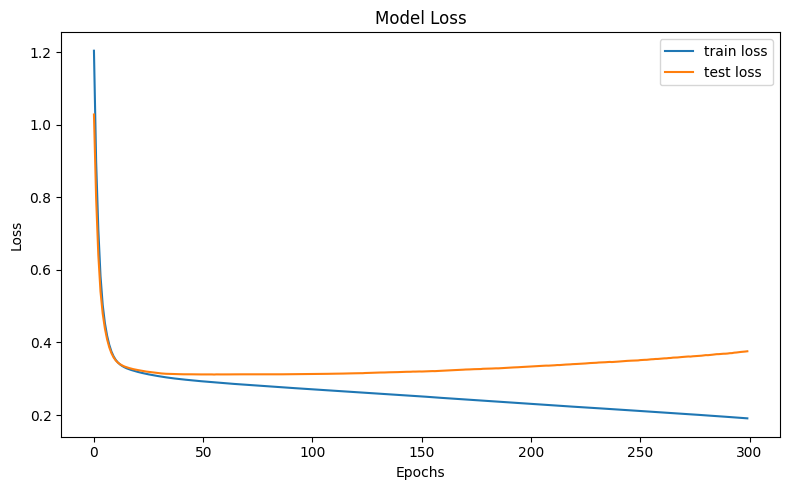

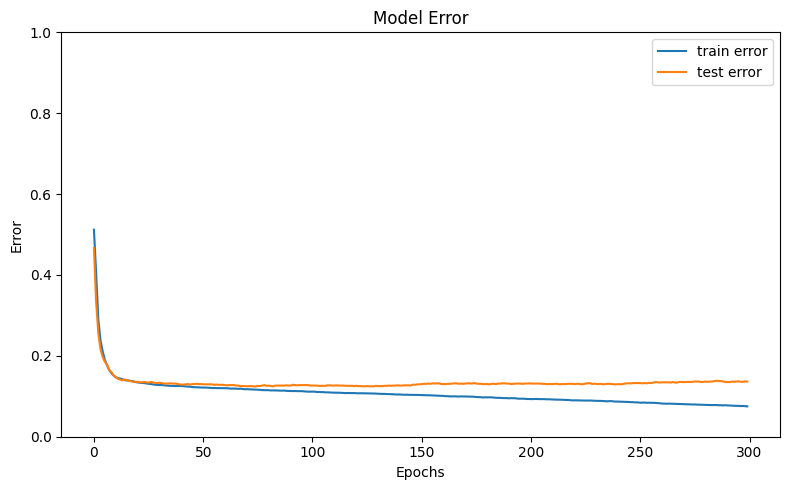

In [36]:
display_results(history_11, start_time_11, end_time_11, IRREDUCIBLE_ERROR)

## Paso 12: Añadimos SGD con momentum 0.9 y volvemos a dos capas 

In [37]:
LEARNING_RATE_12 = 0.01
OPTIMIZER_12 = tf.keras.optimizers.SGD(learning_rate=LEARNING_RATE_12, momentum=0.9)

model_12 = tf.keras.Sequential()
model_12.add(tf.keras.layers.InputLayer(shape=(INPUTS,)))
model_12.add(tf.keras.layers.Dense(64, activation="relu"))
model_12.add(tf.keras.layers.Dense(64, activation="relu"))
model_12.add(tf.keras.layers.Dense(OUTPUTS, activation="softmax"))

model_12.compile(
    loss=tf.keras.losses.categorical_crossentropy,
    optimizer=OPTIMIZER_12,
    metrics=["categorical_accuracy"]
)

model_12.summary()

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_35 (Dense)                │ (None, 64)             │         1,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,892 (23.02 KB)

 Trainable params: 5,892 (23.02 KB)

 Non-trainable params: 0 (0.00 B)

In [38]:
start_time_12 = time.perf_counter()
 
history_12 = model_12.fit(
    x_train, t_train,
    epochs=300,
    verbose=0,
    validation_data=(x_dev, t_dev)
)
 
end_time_12 = time.perf_counter()

Error training:  3.5 %
Error development test:  17.1 %
Error bias:  -6.5 %
Error variance:  13.6 %
Time:  130 seconds
Accuracy training:     96.5 %
Accuracy dev test:     82.9 %


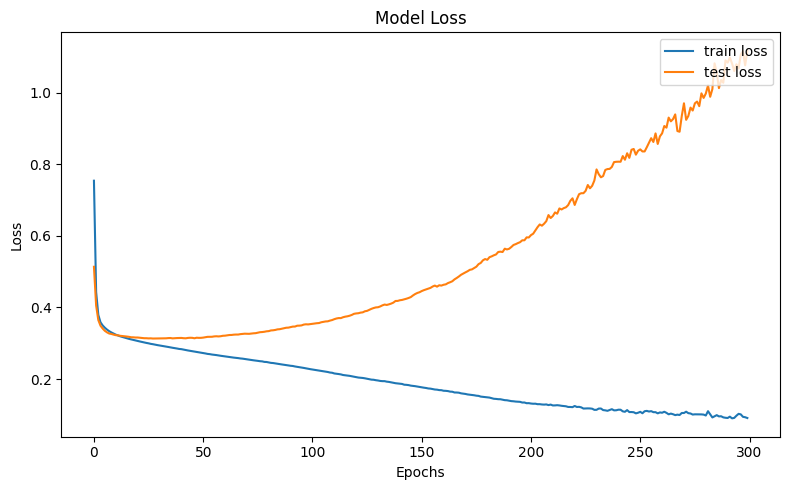

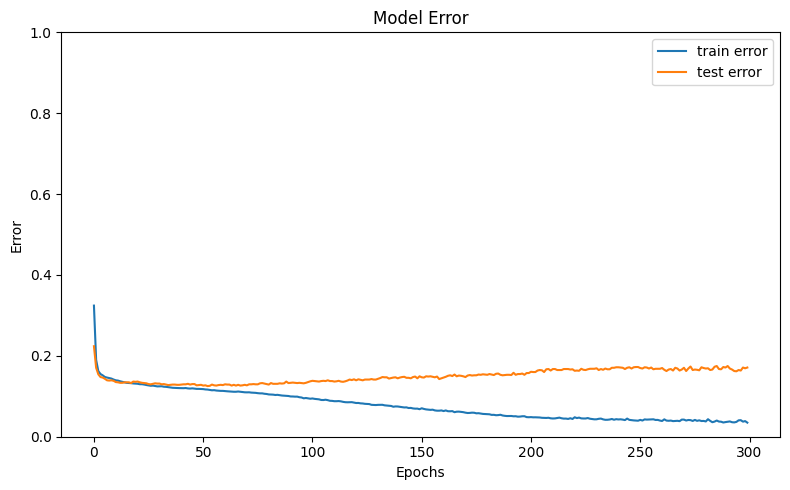

In [39]:
display_results(history_12, start_time_12, end_time_12, IRREDUCIBLE_ERROR)

## Paso 13: Bajamos el LR = 0.001

In [40]:
LEARNING_RATE_13 = 0.001
OPTIMIZER_13 = tf.keras.optimizers.SGD(learning_rate=LEARNING_RATE_13, momentum=0.9)

model_13 = tf.keras.Sequential()
model_13.add(tf.keras.layers.InputLayer(shape=(INPUTS,)))
model_13.add(tf.keras.layers.Dense(64, activation="relu"))
model_13.add(tf.keras.layers.Dense(64, activation="relu"))
model_13.add(tf.keras.layers.Dense(OUTPUTS, activation="softmax"))

model_13.compile(
    loss=tf.keras.losses.categorical_crossentropy,
    optimizer=OPTIMIZER_13,
    metrics=["categorical_accuracy"]
)

model_13.summary()

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_38 (Dense)                │ (None, 64)             │         1,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,892 (23.02 KB)

 Trainable params: 5,892 (23.02 KB)

 Non-trainable params: 0 (0.00 B)

In [41]:
start_time_13 = time.perf_counter()
 
history_13 = model_13.fit(
    x_train, t_train,
    epochs=300,
    verbose=0,
    validation_data=(x_dev, t_dev)
)
 
end_time_13 = time.perf_counter()

Error training:  11.3 %
Error development test:  12.9 %
Error bias:  1.3 %
Error variance:  1.6 %
Time:  130 seconds
Accuracy training:     88.7 %
Accuracy dev test:     87.1 %


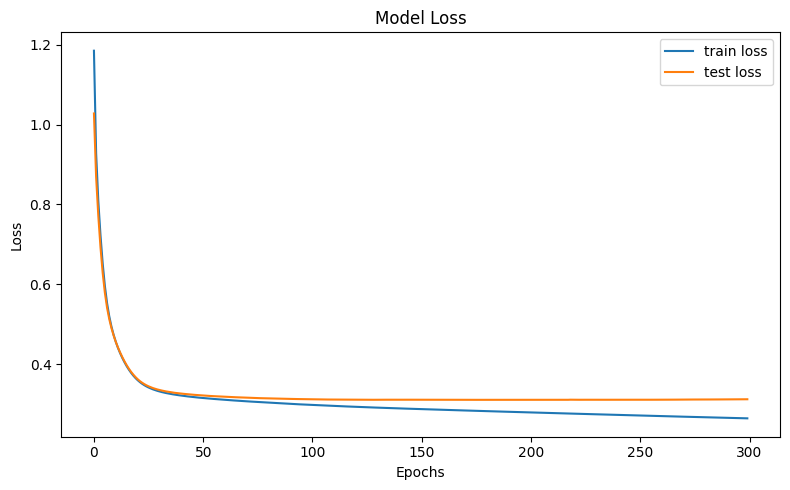

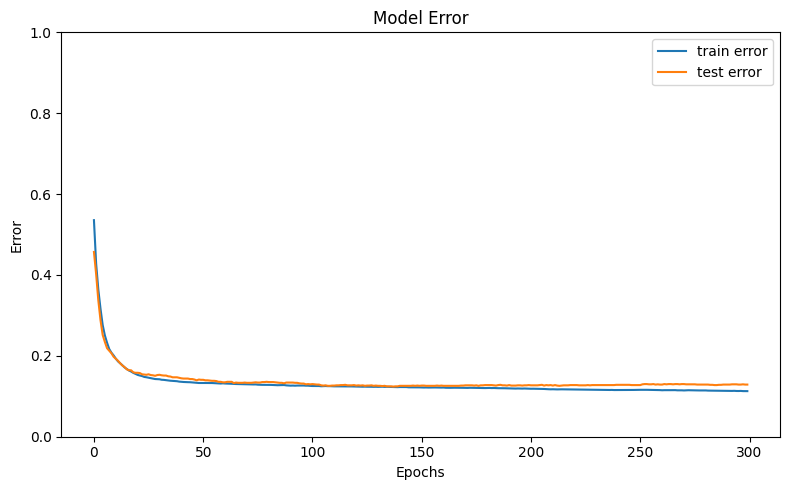

In [42]:
display_results(history_13, start_time_13, end_time_13, IRREDUCIBLE_ERROR)

## Paso 14: Usamos Adam

In [43]:
model_14 = tf.keras.Sequential()
model_14.add(tf.keras.layers.InputLayer(shape=(INPUTS,)))
model_14.add(tf.keras.layers.Dense(64, activation="relu"))
model_14.add(tf.keras.layers.Dense(64, activation="relu"))
model_14.add(tf.keras.layers.Dense(OUTPUTS, activation="softmax"))

model_14.compile(
    loss="categorical_crossentropy",
    optimizer="adam",
    metrics=["categorical_accuracy"]
)
 
model_14.summary()

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_41 (Dense)                │ (None, 64)             │         1,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,892 (23.02 KB)

 Trainable params: 5,892 (23.02 KB)

 Non-trainable params: 0 (0.00 B)

In [44]:
start_time_14 = time.perf_counter()
 
history_14 = model_14.fit(
    x_train, t_train,
    epochs=300,
    verbose=0,
    validation_data=(x_dev, t_dev)
)
 
end_time_14 = time.perf_counter()

Error training:  2.7 %
Error development test:  16.2 %
Error bias:  -7.3 %
Error variance:  13.5 %
Time:  135 seconds
Accuracy training:     97.3 %
Accuracy dev test:     83.8 %


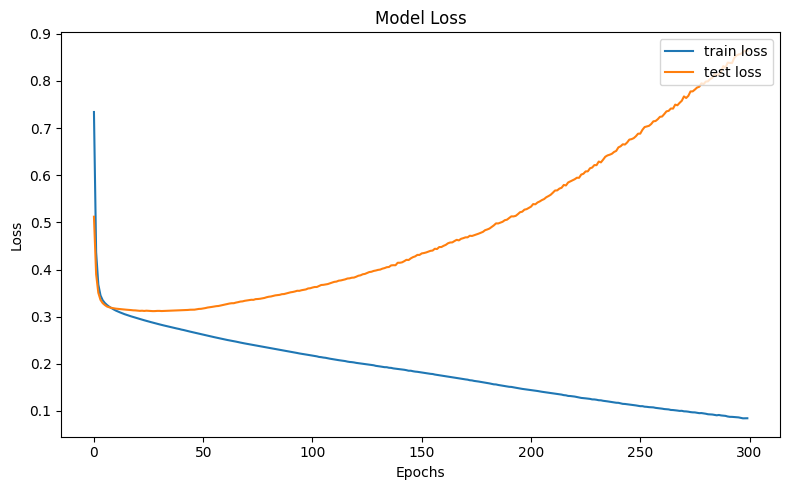

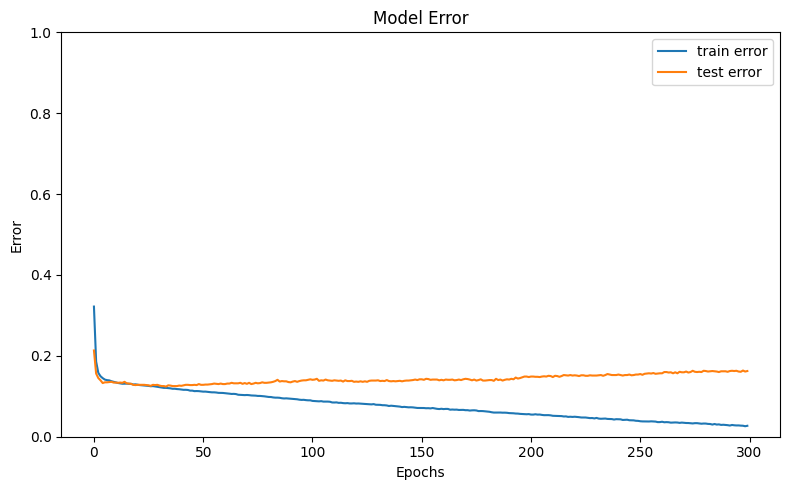

In [45]:
display_results(history_14, start_time_14, end_time_14, IRREDUCIBLE_ERROR)

## Paso 15: Pasamos a Adam con LR = 0.0001

In [46]:
model_15 = tf.keras.Sequential()
model_15.add(tf.keras.layers.InputLayer(shape=(INPUTS,)))
model_15.add(tf.keras.layers.Dense(64, activation="relu"))
model_15.add(tf.keras.layers.Dense(64, activation="relu"))
model_15.add(tf.keras.layers.Dense(OUTPUTS, activation="softmax"))

model_15.compile(
    loss=tf.keras.losses.categorical_crossentropy,
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    metrics=["categorical_accuracy"]
)

model_15.summary()

Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_44 (Dense)                │ (None, 64)             │         1,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_45 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_46 (Dense)                │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,892 (23.02 KB)

 Trainable params: 5,892 (23.02 KB)

 Non-trainable params: 0 (0.00 B)

In [47]:
start_time_15 = time.perf_counter()
 
history_15 = model_15.fit(
    x_train, t_train,
    epochs=300,
    verbose=0,
    validation_data=(x_dev, t_dev)
)
 
end_time_15 = time.perf_counter()

Error training:  11.2 %
Error development test:  13.1 %
Error bias:  1.2 %
Error variance:  1.9 %
Time:  134 seconds
Accuracy training:     88.8 %
Accuracy dev test:     86.9 %


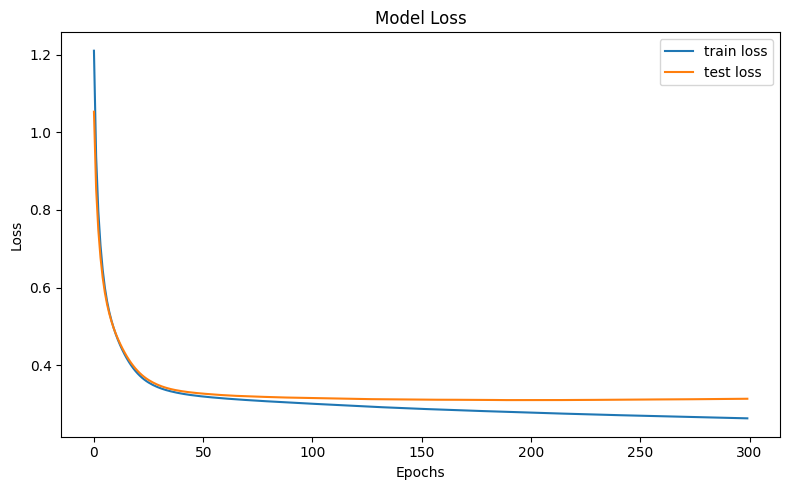

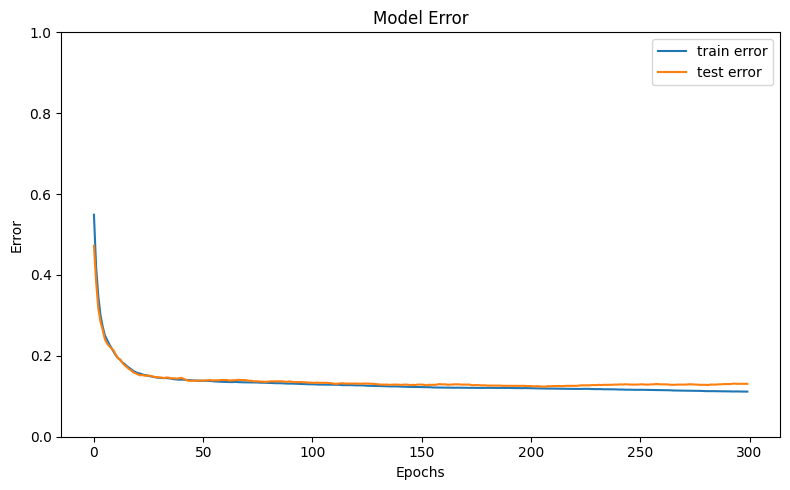

In [48]:
display_results(history_15, start_time_15, end_time_15, IRREDUCIBLE_ERROR)

## Paso 16: Añadimos dropout 0.1

In [49]:
DROPOUT_RATE_16 = 0.1

model_16 = tf.keras.Sequential()
model_16.add(tf.keras.layers.InputLayer(shape=(INPUTS,)))
model_16.add(tf.keras.layers.Dense(64, activation="relu"))
model_16.add(tf.keras.layers.Dropout(DROPOUT_RATE_16))
model_16.add(tf.keras.layers.Dense(64, activation="relu"))
model_16.add(tf.keras.layers.Dropout(DROPOUT_RATE_16))
model_16.add(tf.keras.layers.Dense(OUTPUTS, activation="softmax"))

model_16.compile(
    loss="categorical_crossentropy",
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    metrics=["categorical_accuracy"]
)

In [50]:
start_time_16 = time.perf_counter()
 
history_16 = model_16.fit(
    x_train, t_train,
    epochs=300,
    verbose=0,
    validation_data=(x_dev, t_dev)
)
 
end_time_16 = time.perf_counter()

Error training:  12.9 %
Error development test:  12.5 %
Error bias:  2.9 %
Error variance:  -0.4 %
Time:  136 seconds
Accuracy training:     87.1 %
Accuracy dev test:     87.5 %


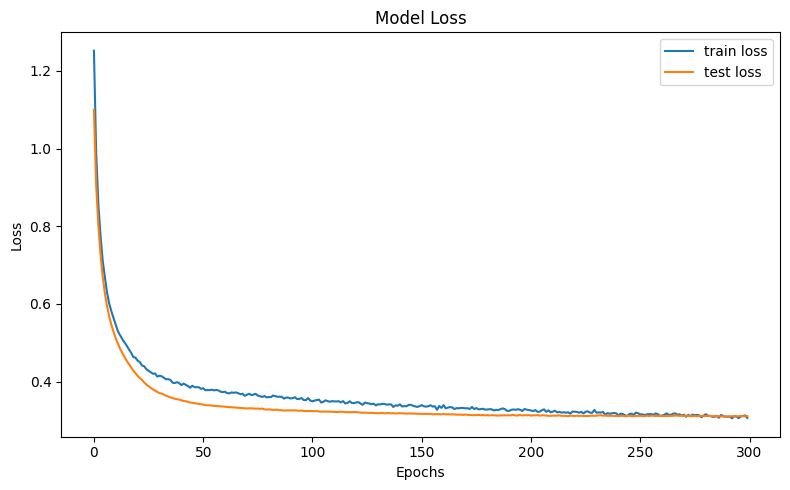

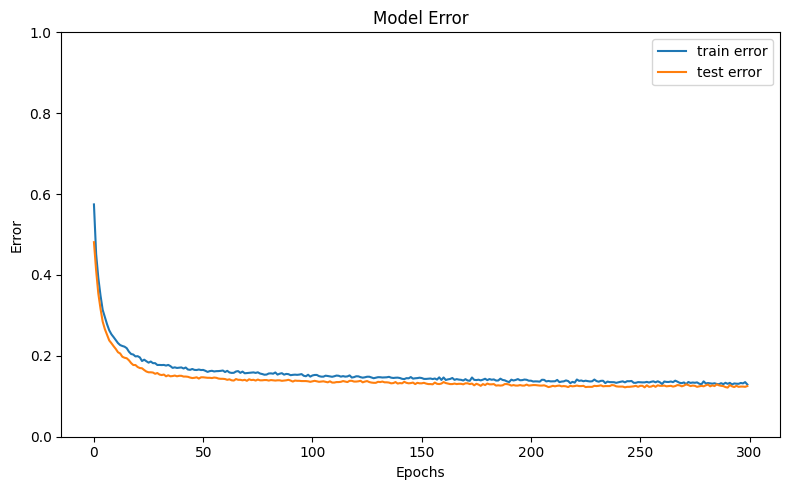

In [51]:
display_results(history_16, start_time_16, end_time_16, IRREDUCIBLE_ERROR)

## Paso 17: Aumentamos la red

In [52]:
model_17 = tf.keras.Sequential()
model_17.add(tf.keras.layers.InputLayer(shape=(INPUTS,)))
model_17.add(tf.keras.layers.Dense(128, activation="relu"))
model_17.add(tf.keras.layers.Dense(64, activation="relu"))
model_17.add(tf.keras.layers.Dense(OUTPUTS, activation="softmax"))

model_17.compile(
    loss="categorical_crossentropy",
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    metrics=["categorical_accuracy"]
)

In [53]:
start_time_17 = time.perf_counter()
 
history_17 = model_17.fit(
    x_train, t_train,
    epochs=300,
    verbose=0,
    validation_data=(x_dev, t_dev)
)
 
end_time_17 = time.perf_counter()

2026-03-24 19:22:15.930748: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-24 19:22:16.554744: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_323', 8 bytes spill stores, 8 bytes spill loads

2026-03-24 19:22:16.595702: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_323', 8 bytes spill stores, 8 bytes spill loads

2026-03-24 19:22:16.726534: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_323', 468 bytes sp

Error training:  9.8 %
Error development test:  13.0 %
Error bias:  -0.2 %
Error variance:  3.1 %
Time:  135 seconds
Accuracy training:     90.2 %
Accuracy dev test:     87.0 %


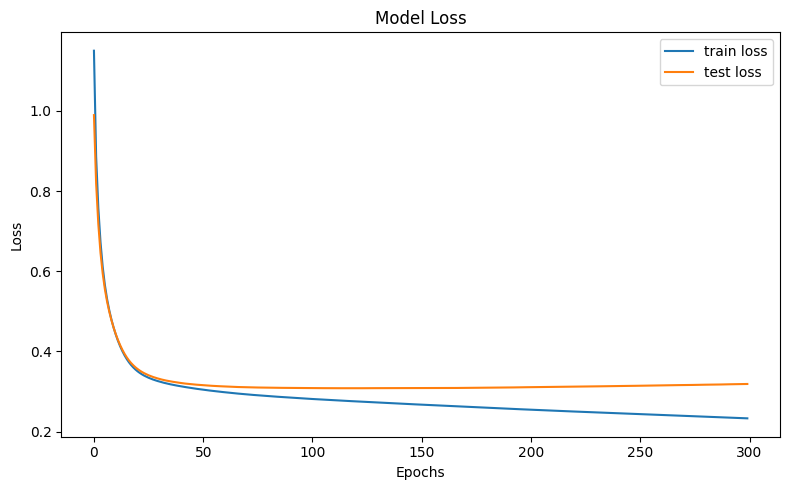

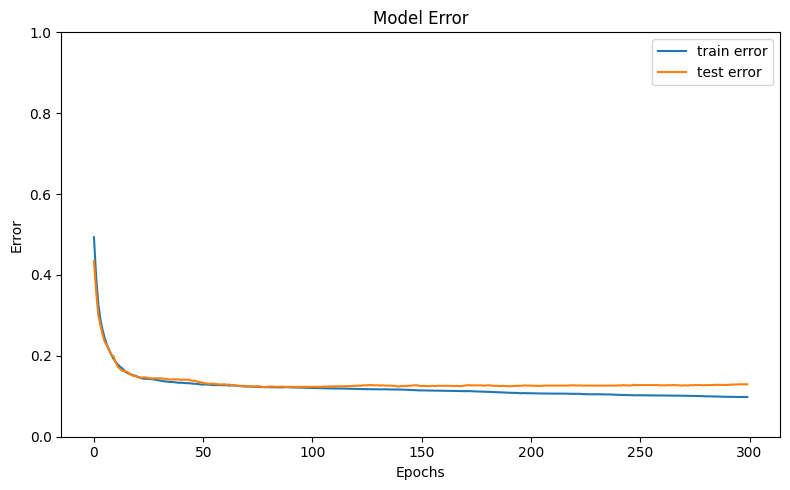

In [54]:
display_results(history_17, start_time_17, end_time_17, IRREDUCIBLE_ERROR)

## Paso 18: aumentamos epochs a 500

In [55]:
model_18 = tf.keras.Sequential()
model_18.add(tf.keras.layers.InputLayer(shape=(INPUTS,)))
model_18.add(tf.keras.layers.Dense(64, activation="relu"))
model_18.add(tf.keras.layers.Dense(64, activation="relu"))
model_18.add(tf.keras.layers.Dense(OUTPUTS, activation="softmax"))

model_18.compile(
    loss=tf.keras.losses.categorical_crossentropy,
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    metrics=["categorical_accuracy"]
)

model_18.summary()

Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_53 (Dense)                │ (None, 64)             │         1,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_54 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_55 (Dense)                │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,892 (23.02 KB)

 Trainable params: 5,892 (23.02 KB)

 Non-trainable params: 0 (0.00 B)

In [56]:
start_time_18 = time.perf_counter()
 
history_18 = model_18.fit(
    x_train, t_train,
    epochs=500,
    verbose=0,
    validation_data=(x_dev, t_dev)
)
 
end_time_18 = time.perf_counter()

Error training:  10.4 %
Error development test:  13.0 %
Error bias:  0.4 %
Error variance:  2.6 %
Time:  222 seconds
Accuracy training:     89.6 %
Accuracy dev test:     87.0 %


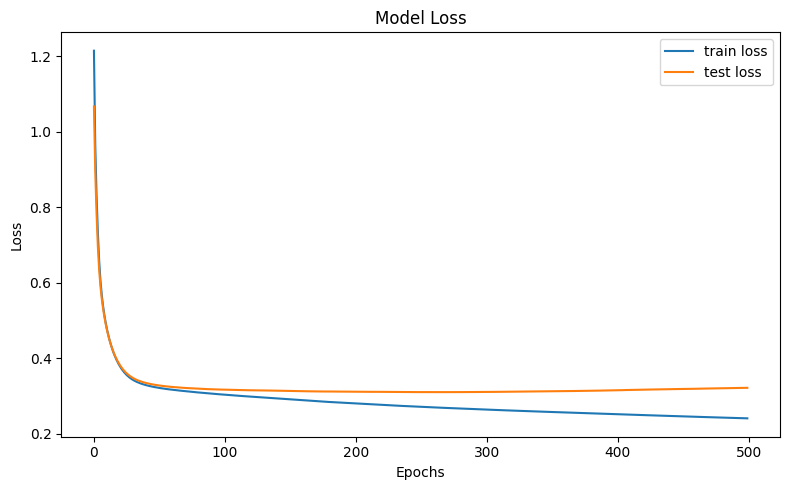

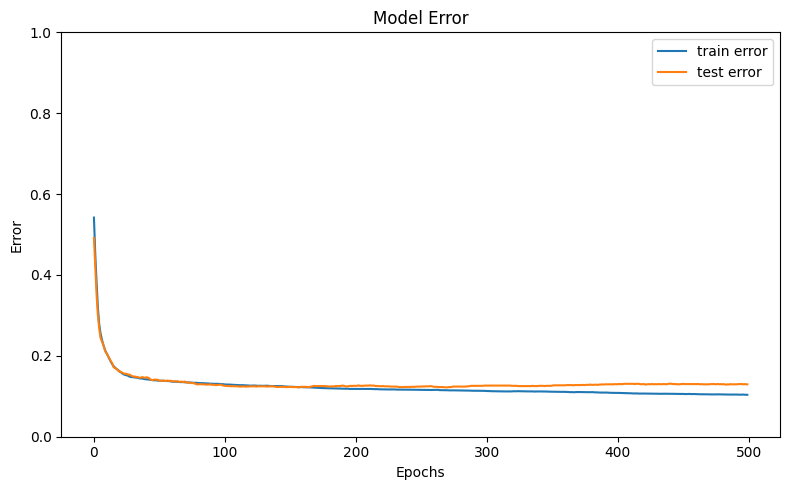

In [57]:
display_results(history_18, start_time_18, end_time_18, IRREDUCIBLE_ERROR)

## Paso 19: Disminuimos batch size a 16

In [58]:
model_19 = tf.keras.Sequential()
model_19.add(tf.keras.layers.InputLayer(shape=(INPUTS,)))
model_19.add(tf.keras.layers.Dense(64, activation="relu"))
model_19.add(tf.keras.layers.Dense(64, activation="relu"))
model_19.add(tf.keras.layers.Dense(OUTPUTS, activation="softmax"))

model_19.compile(
    loss=tf.keras.losses.categorical_crossentropy,
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    metrics=["categorical_accuracy"]
)

model_19.summary()

Model: "sequential_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_56 (Dense)                │ (None, 64)             │         1,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_57 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_58 (Dense)                │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,892 (23.02 KB)

 Trainable params: 5,892 (23.02 KB)

 Non-trainable params: 0 (0.00 B)

In [59]:
start_time_19 = time.perf_counter()
 
history_19 = model_19.fit(
    x_train, t_train,
    batch_size=16,
    epochs=300,
    verbose=0,
    validation_data=(x_dev, t_dev)
)
 
end_time_19 = time.perf_counter()

Error training:  10.5 %
Error development test:  13.8 %
Error bias:  0.5 %
Error variance:  3.4 %
Time:  246 seconds
Accuracy training:     89.5 %
Accuracy dev test:     86.2 %


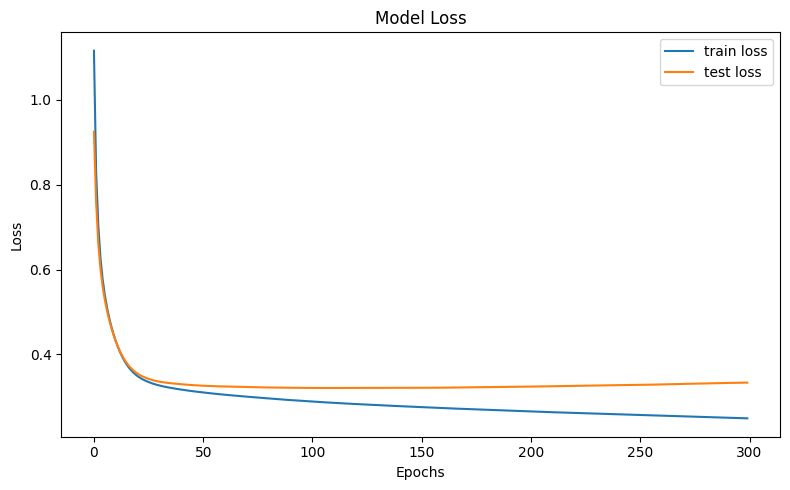

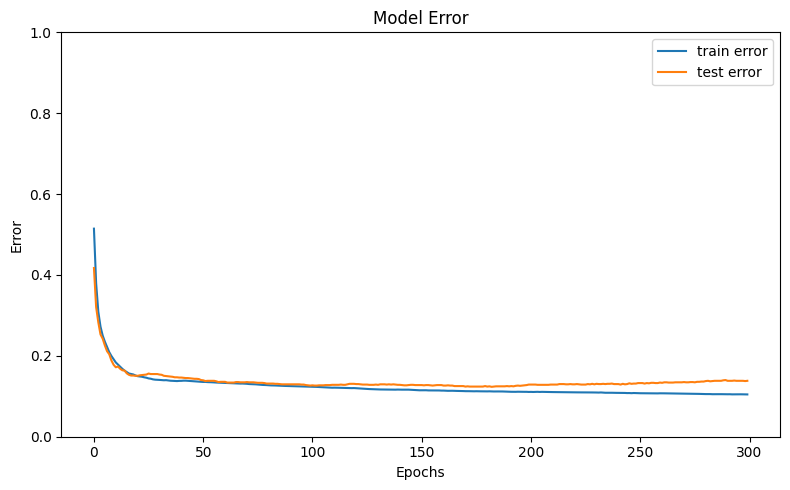

In [60]:
display_results(history_19, start_time_19, end_time_19, IRREDUCIBLE_ERROR)

## Paso 20: red más profunda y dropout suave

In [61]:
DROPOUT_RATE_20 = 0.05

model_20 = tf.keras.Sequential()
model_20.add(tf.keras.layers.InputLayer(shape=(INPUTS,)))
model_20.add(tf.keras.layers.Dense(128, activation="relu"))
model_20.add(tf.keras.layers.Dropout(DROPOUT_RATE_20))
model_20.add(tf.keras.layers.Dense(64, activation="relu"))
model_20.add(tf.keras.layers.Dropout(DROPOUT_RATE_20))
model_20.add(tf.keras.layers.Dense(32, activation="relu"))
model_20.add(tf.keras.layers.Dense(OUTPUTS, activation="softmax"))

model_20.compile(
    loss="categorical_crossentropy",
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    metrics=["categorical_accuracy"]
)

In [62]:
start_time_20 = time.perf_counter()
 
history_20 = model_20.fit(
    x_train, t_train,
    epochs=300,
    verbose=0,
    validation_data=(x_dev, t_dev)
)
 
end_time_20 = time.perf_counter()

2026-03-24 19:32:20.472733: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-24 19:32:21.443195: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1110', 520 bytes spill stores, 520 bytes spill loads



Error training:  10.3 %
Error development test:  12.7 %
Error bias:  0.3 %
Error variance:  2.4 %
Time:  145 seconds
Accuracy training:     89.7 %
Accuracy dev test:     87.3 %


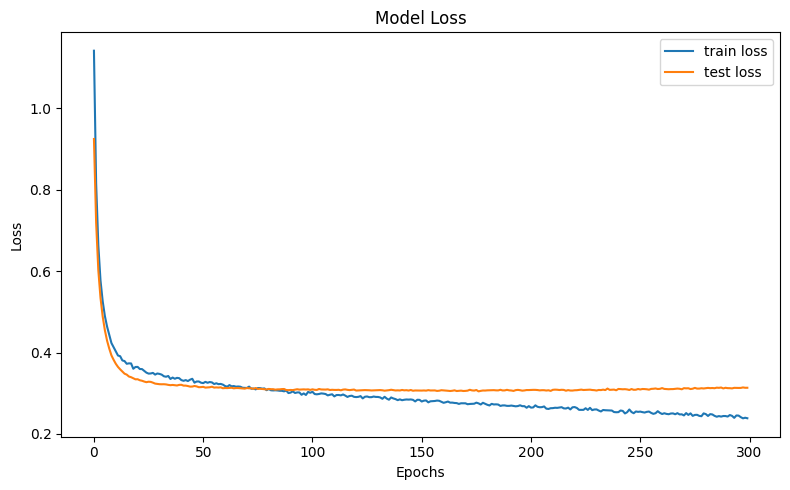

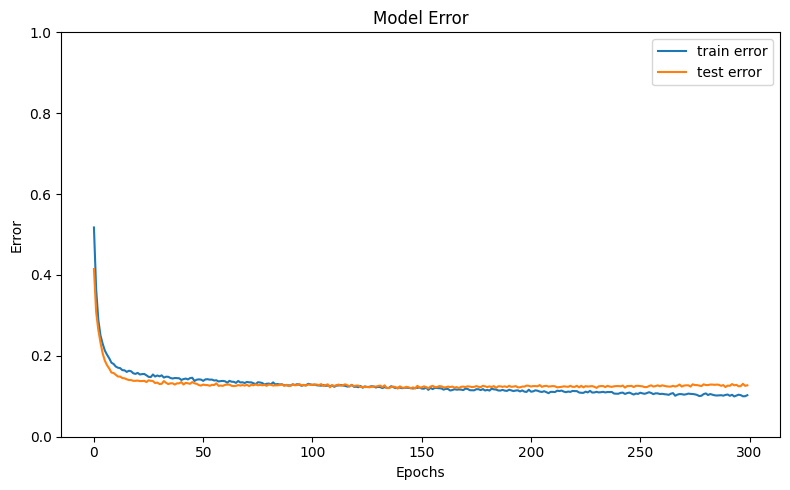

In [63]:
display_results(history_20, start_time_20, end_time_20, IRREDUCIBLE_ERROR)

# Paso 21: Probamos batchnormalization

In [64]:
model_21 = tf.keras.Sequential()
model_21.add(tf.keras.layers.InputLayer(shape=(INPUTS,)))
model_21.add(tf.keras.layers.Dense(128, activation="relu"))
model_21.add(tf.keras.layers.BatchNormalization())
model_21.add(tf.keras.layers.Dense(64, activation="relu"))
model_21.add(tf.keras.layers.BatchNormalization())
model_21.add(tf.keras.layers.Dense(OUTPUTS, activation="softmax"))

model_21.compile(
    loss="categorical_crossentropy",
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    metrics=["categorical_accuracy"]
)

In [65]:
start_time_21 = time.perf_counter()
 
history_21 = model_21.fit(
    x_train, t_train,
    epochs=300,
    verbose=0,
    validation_data=(x_dev, t_dev)
)
 
end_time_21 = time.perf_counter()

Error training:  0.0 %
Error development test:  19.7 %
Error bias:  -10.0 %
Error variance:  19.7 %
Time:  148 seconds
Accuracy training:     100.0 %
Accuracy dev test:     80.3 %


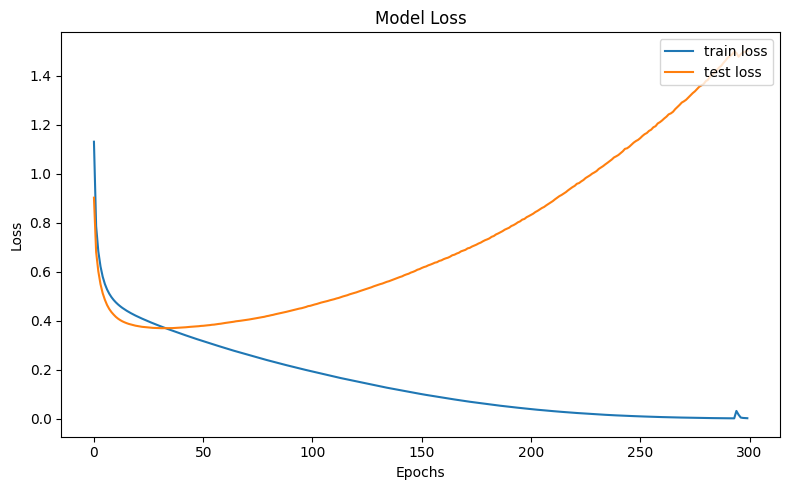

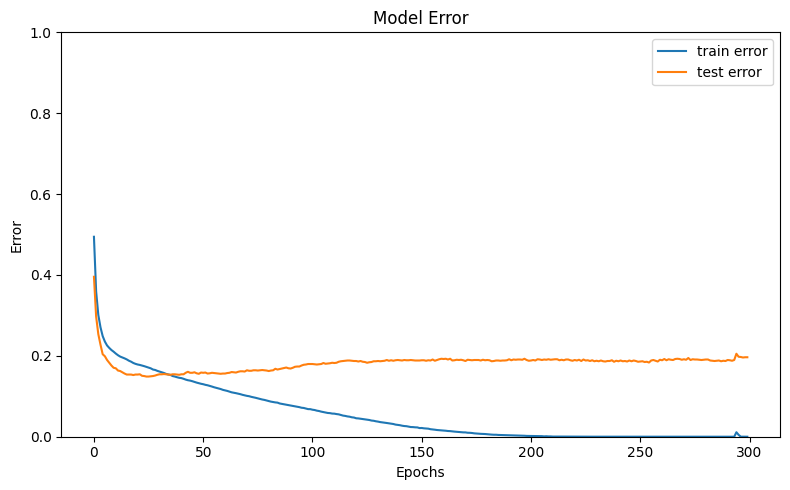

In [66]:
display_results(history_21, start_time_21, end_time_21, IRREDUCIBLE_ERROR)

## Paso 22: Añadimos dropout agresivo 0.3 a batchnormalization

In [67]:
model_22 = tf.keras.Sequential()
model_22.add(tf.keras.layers.InputLayer(shape=(INPUTS,)))
model_22.add(tf.keras.layers.Dense(128, activation="relu"))
model_22.add(tf.keras.layers.BatchNormalization())
model_22.add(tf.keras.layers.Dropout(0.3))
model_22.add(tf.keras.layers.Dense(64, activation="relu"))
model_22.add(tf.keras.layers.BatchNormalization())
model_22.add(tf.keras.layers.Dropout(0.3))
model_22.add(tf.keras.layers.Dense(OUTPUTS, activation="softmax"))

model_22.compile(
    loss="categorical_crossentropy",
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    metrics=["categorical_accuracy"]
)

In [68]:
start_time_22 = time.perf_counter()
 
history_22 = model_22.fit(
    x_train, t_train,
    epochs=300,
    verbose=0,
    validation_data=(x_dev, t_dev)
)
 
end_time_22 = time.perf_counter()

Error training:  14.0 %
Error development test:  13.3 %
Error bias:  4.0 %
Error variance:  -0.7 %
Time:  152 seconds
Accuracy training:     86.0 %
Accuracy dev test:     86.7 %


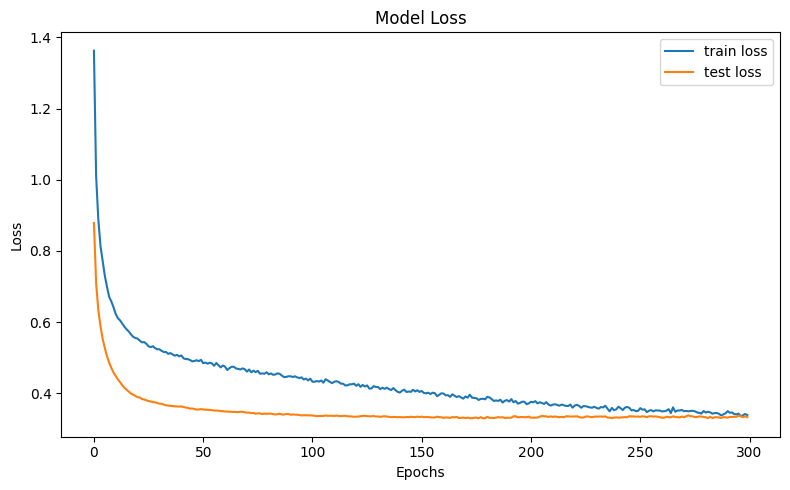

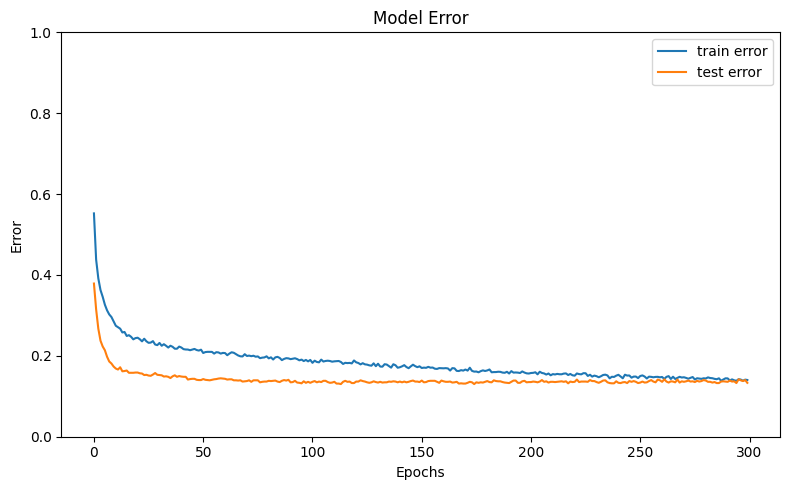

In [69]:
display_results(history_22, start_time_22, end_time_22, IRREDUCIBLE_ERROR)

## Paso 23: Bajamos el dropout a 0.2

In [70]:
model_23 = tf.keras.Sequential()
model_23.add(tf.keras.layers.InputLayer(shape=(INPUTS,)))
model_23.add(tf.keras.layers.Dense(128, activation="relu"))
model_23.add(tf.keras.layers.BatchNormalization())
model_23.add(tf.keras.layers.Dropout(0.2))
model_23.add(tf.keras.layers.Dense(64, activation="relu"))
model_23.add(tf.keras.layers.BatchNormalization())
model_23.add(tf.keras.layers.Dropout(0.2))
model_23.add(tf.keras.layers.Dense(OUTPUTS, activation="softmax"))

model_23.compile(
    loss="categorical_crossentropy",
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    metrics=["categorical_accuracy"]
)

In [71]:
start_time_23 = time.perf_counter()
 
history_23 = model_23.fit(
    x_train, t_train,
    epochs=300,
    verbose=0,
    validation_data=(x_dev, t_dev)
)
 
end_time_23 = time.perf_counter()

Error training:  12.5 %
Error development test:  14.5 %
Error bias:  2.5 %
Error variance:  2.0 %
Time:  152 seconds
Accuracy training:     87.5 %
Accuracy dev test:     85.5 %


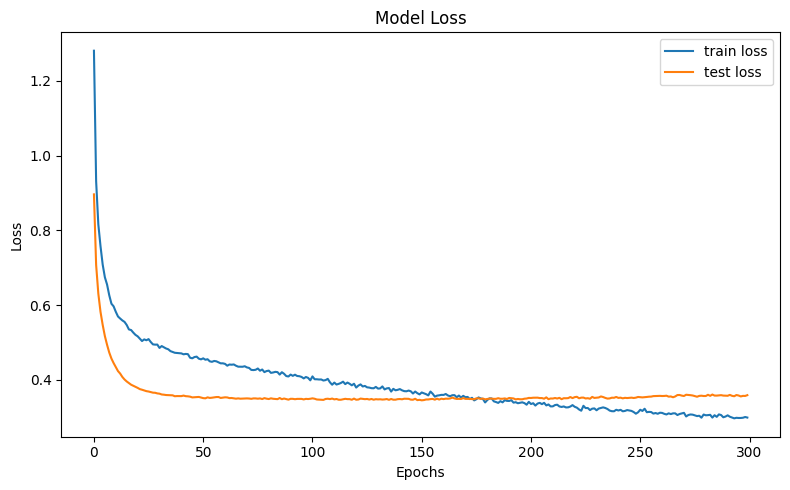

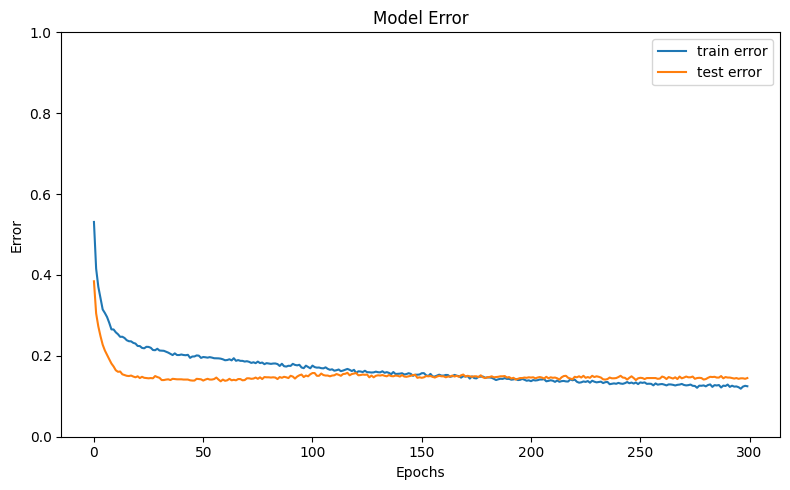

In [72]:
display_results(history_23, start_time_23, end_time_23, IRREDUCIBLE_ERROR)

## Paso 24: probamos earlystopping

In [73]:
model_24 = tf.keras.Sequential()
model_24.add(tf.keras.layers.InputLayer(shape=(INPUTS,)))
model_24.add(tf.keras.layers.Dense(64, activation="relu"))
model_24.add(tf.keras.layers.Dense(64, activation="relu"))
model_24.add(tf.keras.layers.Dense(OUTPUTS, activation="softmax"))

model_24.compile(
    loss=tf.keras.losses.categorical_crossentropy,
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    metrics=["categorical_accuracy"]
)

model_24.summary()

Model: "sequential_23"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_72 (Dense)                │ (None, 64)             │         1,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_73 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_74 (Dense)                │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,892 (23.02 KB)

 Trainable params: 5,892 (23.02 KB)

 Non-trainable params: 0 (0.00 B)

In [77]:
early_stopping_24 = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=20,
    restore_best_weights=True
)

EPOCHS_24 = 500  # epochs máximos, early stopping parará antes
start_time_24 = time.perf_counter()

history_24 = model_24.fit(
    x_train, t_train,
    batch_size=32,
    epochs=EPOCHS_24,
    verbose=0,
    validation_data=(x_dev, t_dev),
    callbacks=[early_stopping_24]
)

print("Epochs ejecutados:", len(history_24.history["loss"]))
end_time_24 = time.perf_counter()
print("Tiempo de ejecución:", end_time_24 - start_time_24)

Epochs ejecutados: 24
Tiempo de ejecución: 12.895055531000253


Error training:  11.8 %
Error development test:  12.3 %
Error bias:  1.8 %
Error variance:  0.6 %
Time:  13 seconds
Accuracy training:     88.2 %
Accuracy dev test:     87.7 %


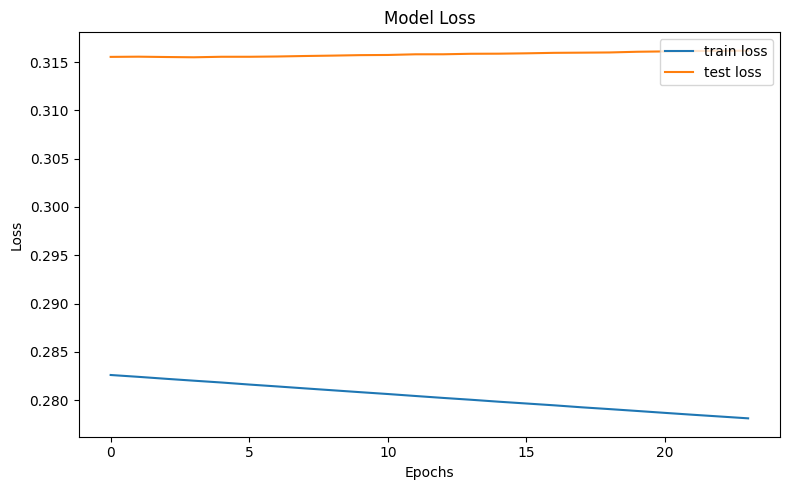

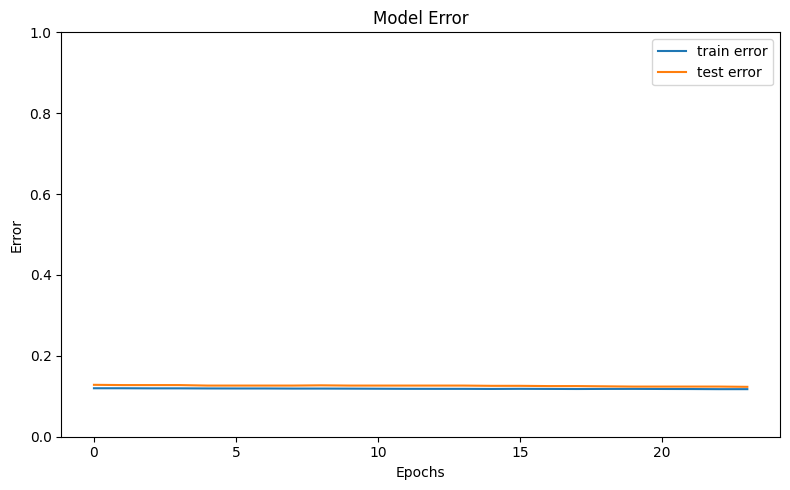

In [78]:
display_results(history_24, start_time_24, end_time_24, IRREDUCIBLE_ERROR)

## Paso 25: Probamos learning rate decay

In [79]:
model_25 = tf.keras.Sequential()
model_25.add(tf.keras.layers.InputLayer(shape=(INPUTS,)))
model_25.add(tf.keras.layers.Dense(64, activation="relu"))
model_25.add(tf.keras.layers.Dense(64, activation="relu"))
model_25.add(tf.keras.layers.Dense(OUTPUTS, activation="softmax"))

model_25.compile(
    loss="categorical_crossentropy",
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    metrics=["categorical_accuracy"]
)

model_25.summary()

Model: "sequential_24"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_75 (Dense)                │ (None, 64)             │         1,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_76 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_77 (Dense)                │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,892 (23.02 KB)

 Trainable params: 5,892 (23.02 KB)

 Non-trainable params: 0 (0.00 B)

In [80]:
early_stopping_25 = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=30,
    restore_best_weights=True
)

lr_scheduler_25 = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=10,
    min_lr=1e-6,
    verbose=1
)

start_time_25 = time.perf_counter()

history_25 = model_25.fit(
    x_train, t_train,
    batch_size=32,
    epochs=500,
    verbose=0,
    validation_data=(x_dev, t_dev),
    callbacks=[early_stopping_25, lr_scheduler_25]
)

end_time_25 = time.perf_counter()

print("Epochs ejecutados:", len(history_25.history["loss"]))


Epoch 29: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 40: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 50: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 60: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.
Epochs ejecutados: 60


Error training:  10.9 %
Error development test:  12.7 %
Error bias:  0.9 %
Error variance:  1.8 %
Time:  34 seconds
Accuracy training:     89.1 %
Accuracy dev test:     87.3 %


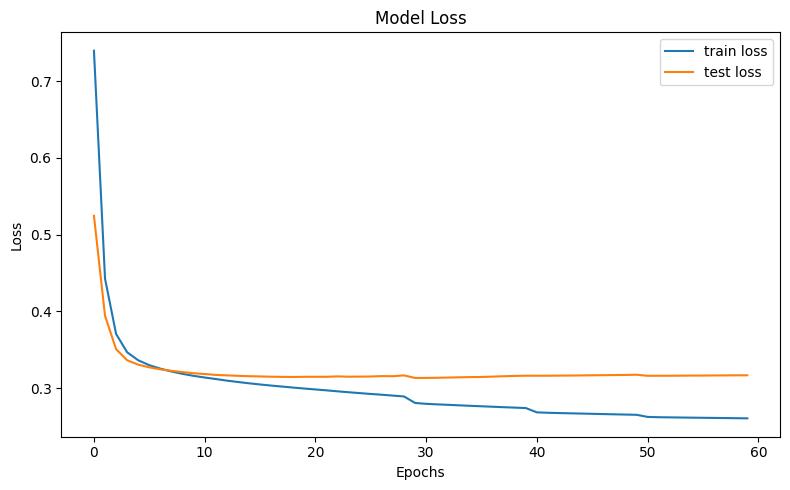

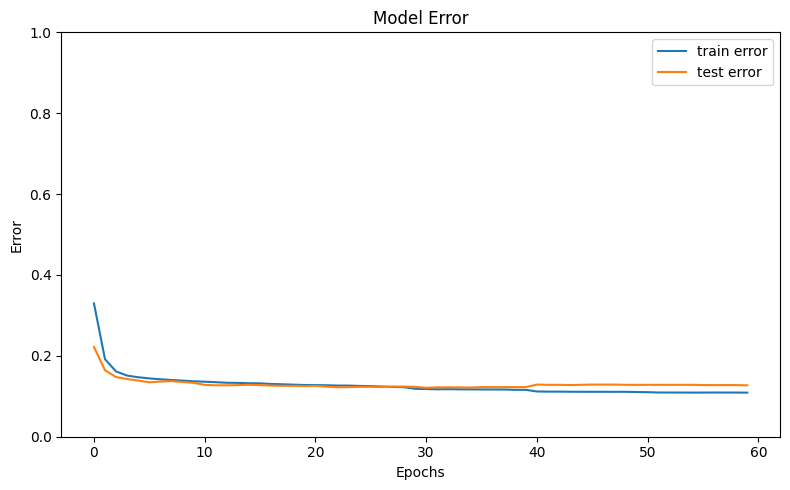

In [81]:
display_results(history_25, start_time_25, end_time_25, IRREDUCIBLE_ERROR)

## Paso 26: probamos weight initializers 

In [82]:
INITIALIZER_26 = tf.keras.initializers.HeNormal()

model_26 = tf.keras.Sequential()
model_26.add(tf.keras.layers.InputLayer(shape=(INPUTS,)))
model_26.add(tf.keras.layers.Dense(64, activation="relu", kernel_initializer=INITIALIZER_26))
model_26.add(tf.keras.layers.Dense(64, activation="relu", kernel_initializer=INITIALIZER_26))
model_26.add(tf.keras.layers.Dense(OUTPUTS, activation="softmax"))

model_26.compile(
    loss="categorical_crossentropy",
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    metrics=["categorical_accuracy"]
)

In [83]:
start_time_26 = time.perf_counter()
 
history_26 = model_26.fit(
    x_train, t_train,
    epochs=300,
    batch_size=32,
    verbose=0,
    validation_data=(x_dev, t_dev)
)
 
end_time_26 = time.perf_counter()

Error training:  10.4 %
Error development test:  13.1 %
Error bias:  0.4 %
Error variance:  2.7 %
Time:  141 seconds
Accuracy training:     89.6 %
Accuracy dev test:     86.9 %


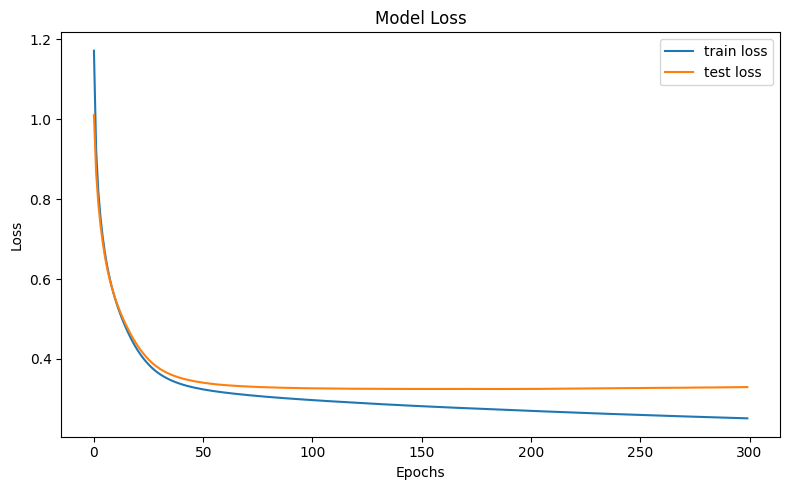

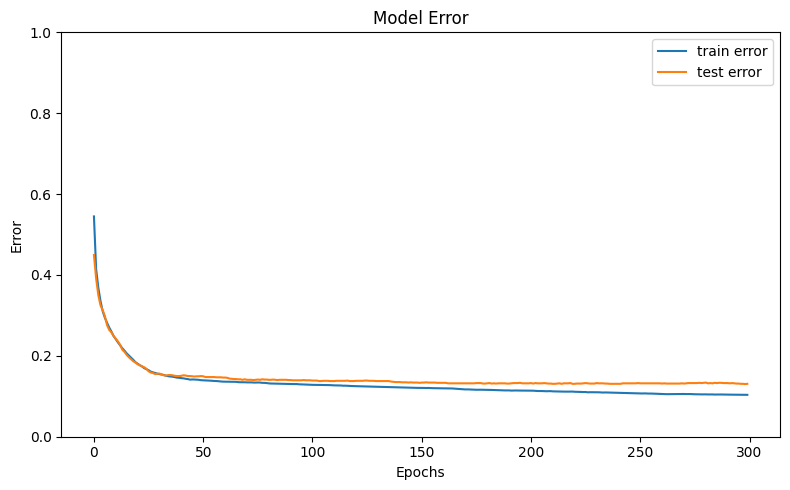

In [84]:
display_results(history_26, start_time_26, end_time_26, IRREDUCIBLE_ERROR)

## Paso 27: L2 + dropout en 2x64

In [85]:
REGULARIZER_27 = tf.keras.regularizers.L2(0.0001)
DROPOUT_RATE_27 = 0.1

model_27 = tf.keras.Sequential()
model_27.add(tf.keras.layers.InputLayer(shape=(INPUTS,)))
model_27.add(tf.keras.layers.Dense(64, activation="relu", kernel_regularizer=REGULARIZER_27))
model_27.add(tf.keras.layers.Dropout(DROPOUT_RATE_27))
model_27.add(tf.keras.layers.Dense(64, activation="relu", kernel_regularizer=REGULARIZER_27))
model_27.add(tf.keras.layers.Dropout(DROPOUT_RATE_27))
model_27.add(tf.keras.layers.Dense(OUTPUTS, activation="softmax"))

model_27.compile(
    loss="categorical_crossentropy",
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    metrics=["categorical_accuracy"]
)

In [86]:
start_time_27 = time.perf_counter()
 
history_27 = model_27.fit(
    x_train, t_train,
    epochs=300,
    batch_size=32,
    verbose=0,
    validation_data=(x_dev, t_dev)
)
 
end_time_27 = time.perf_counter()

Error training:  12.9 %
Error development test:  12.2 %
Error bias:  2.9 %
Error variance:  -0.7 %
Time:  150 seconds
Accuracy training:     87.1 %
Accuracy dev test:     87.8 %


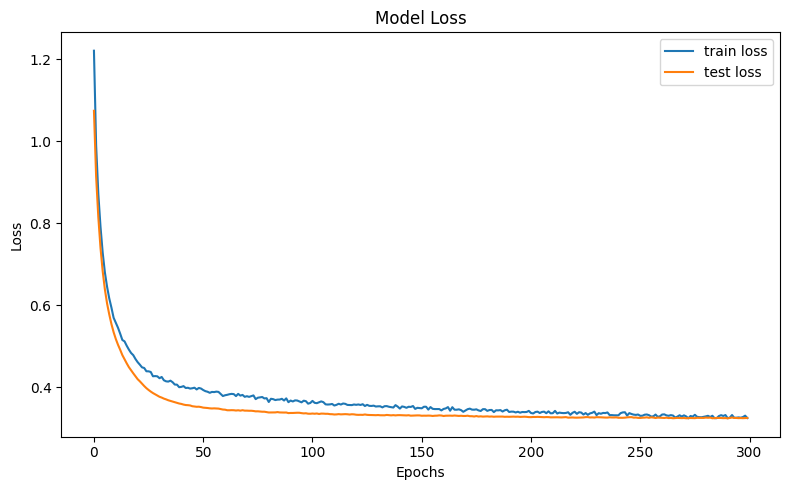

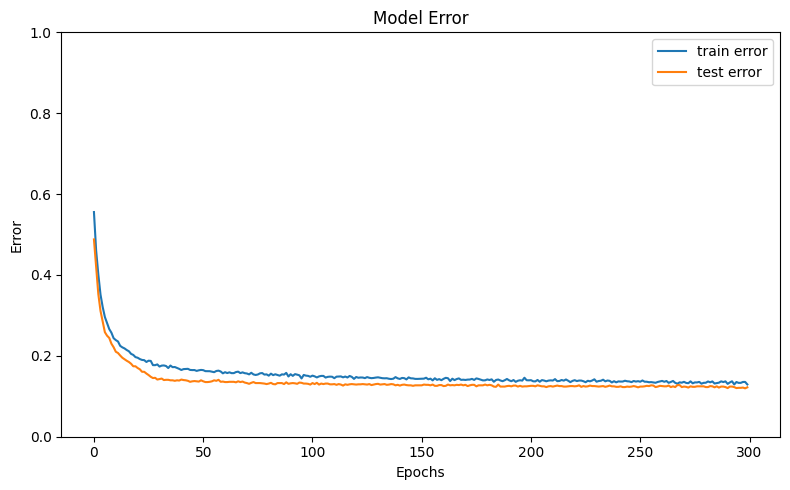

In [87]:
display_results(history_27, start_time_27, end_time_27, IRREDUCIBLE_ERROR)

## Paso 28: Batchnormalization antes de activacion

In [88]:
model_28 = tf.keras.Sequential()
model_28.add(tf.keras.layers.InputLayer(shape=(INPUTS,)))
model_28.add(tf.keras.layers.Dense(64))
model_28.add(tf.keras.layers.BatchNormalization())
model_28.add(tf.keras.layers.Activation("relu"))
model_28.add(tf.keras.layers.Dense(64))
model_28.add(tf.keras.layers.BatchNormalization())
model_28.add(tf.keras.layers.Activation("relu"))
model_28.add(tf.keras.layers.Dense(OUTPUTS, activation="softmax"))

model_28.compile(
    loss="categorical_crossentropy",
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    metrics=["categorical_accuracy"]
)

In [89]:
start_time_28 = time.perf_counter()
 
history_28 = model_28.fit(
    x_train, t_train,
    epochs=300,
    batch_size=32,
    verbose=0,
    validation_data=(x_dev, t_dev)
)
 
end_time_28 = time.perf_counter()

Error training:  11.9 %
Error development test:  19.3 %
Error bias:  1.9 %
Error variance:  7.4 %
Time:  150 seconds
Accuracy training:     88.1 %
Accuracy dev test:     80.7 %


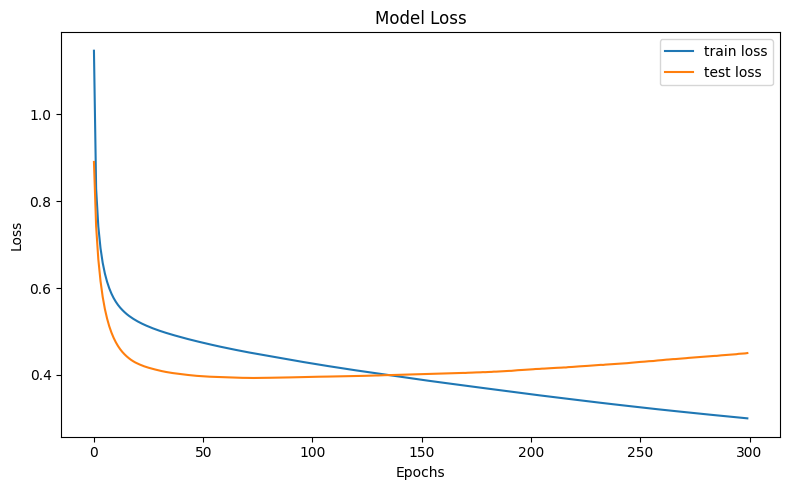

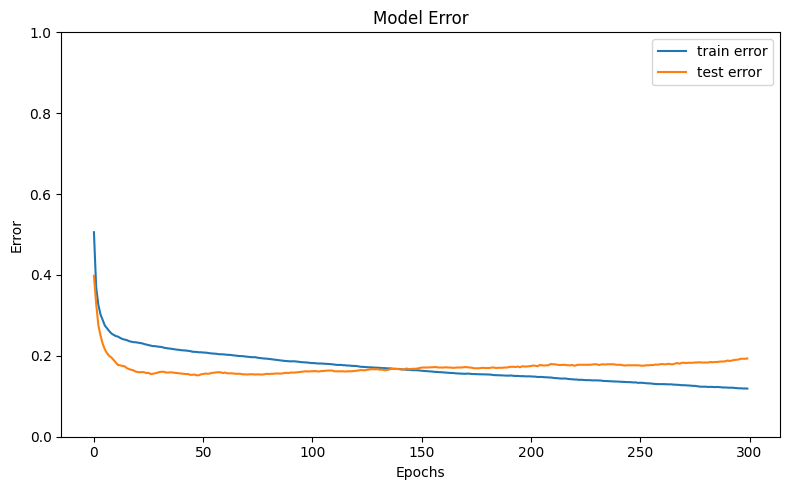

In [90]:
display_results(history_28, start_time_28, end_time_28, IRREDUCIBLE_ERROR)

## Paso 29: probamos RMSprop

In [91]:
model_29 = tf.keras.Sequential()
model_29.add(tf.keras.layers.InputLayer(shape=(INPUTS,)))
model_29.add(tf.keras.layers.Dense(64, activation="relu"))
model_29.add(tf.keras.layers.Dense(64, activation="relu"))
model_29.add(tf.keras.layers.Dense(OUTPUTS, activation="softmax"))

model_29.compile(
    loss="categorical_crossentropy",
    optimizer=tf.keras.optimizers.RMSprop(learning_rate=0.0001),
    metrics=["categorical_accuracy"]
)

In [92]:
start_time_29 = time.perf_counter()
 
history_29 = model_29.fit(
    x_train, t_train,
    epochs=300,
    batch_size=32,
    verbose=0,
    validation_data=(x_dev, t_dev)
)
 
end_time_29 = time.perf_counter()

Error training:  11.3 %
Error development test:  13.0 %
Error bias:  1.3 %
Error variance:  1.7 %
Time:  131 seconds
Accuracy training:     88.7 %
Accuracy dev test:     87.0 %


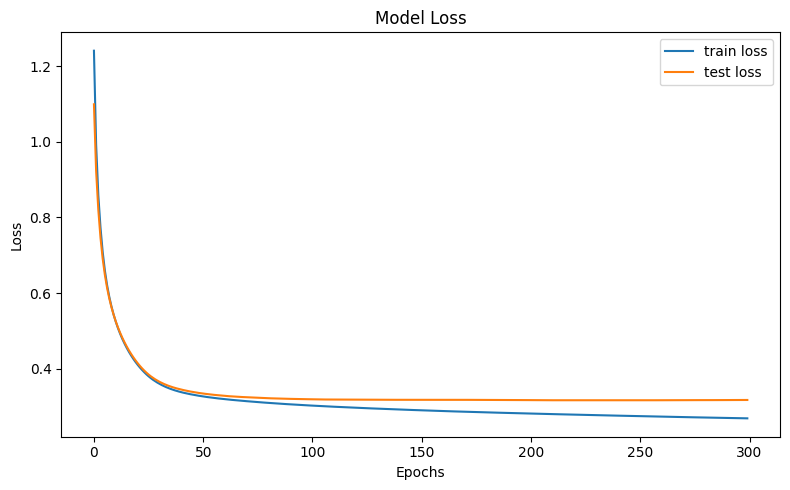

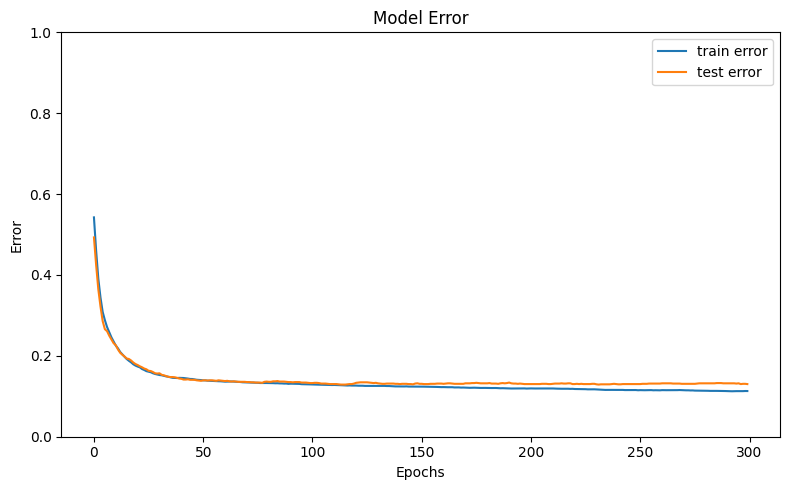

In [93]:
display_results(history_29, start_time_29, end_time_29, IRREDUCIBLE_ERROR)   

## Paso 30: probamos con ELU

In [94]:
model_30 = tf.keras.Sequential()
model_30.add(tf.keras.layers.InputLayer(shape=(INPUTS,)))
model_30.add(tf.keras.layers.Dense(64, activation="elu"))
model_30.add(tf.keras.layers.Dense(64, activation="elu"))
model_30.add(tf.keras.layers.Dense(OUTPUTS, activation="softmax"))

model_30.compile(
    loss="categorical_crossentropy",
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    metrics=["categorical_accuracy"]
)

In [95]:
start_time_30 = time.perf_counter()
 
history_30 = model_30.fit(
    x_train, t_train,
    epochs=300,
    batch_size=32,
    verbose=0,
    validation_data=(x_dev, t_dev)
)
 
end_time_30 = time.perf_counter()

Error training:  13.1 %
Error development test:  13.4 %
Error bias:  3.1 %
Error variance:  0.3 %
Time:  135 seconds
Accuracy training:     86.9 %
Accuracy dev test:     86.6 %


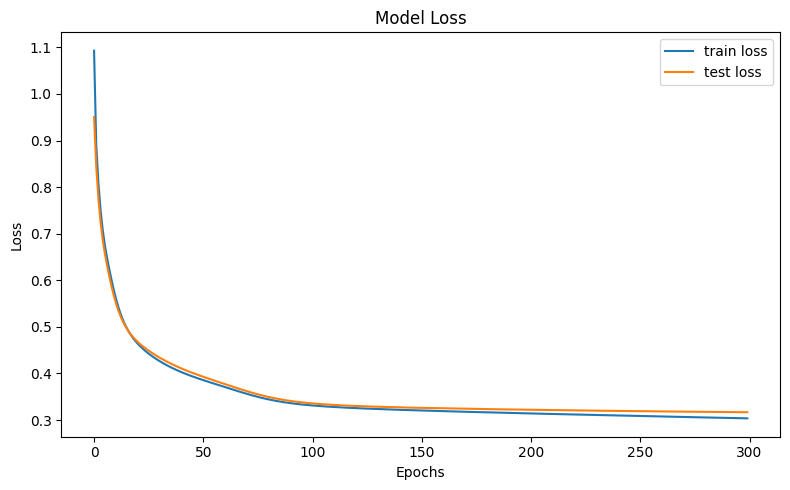

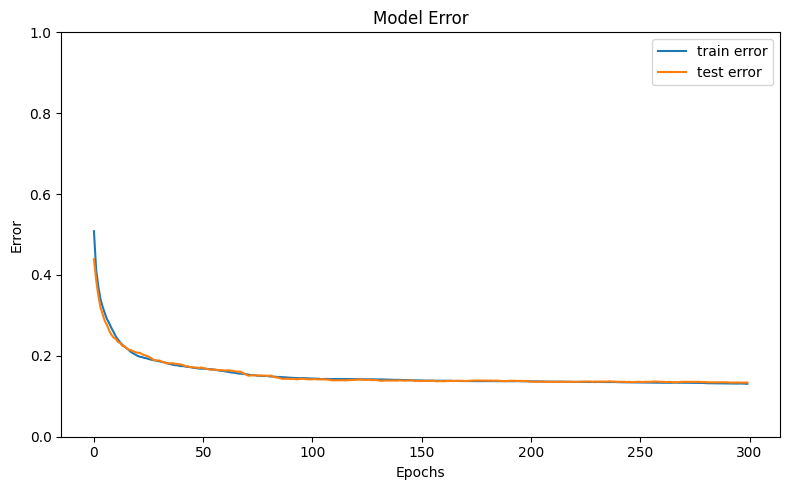

In [96]:
display_results(history_30, start_time_30, end_time_30, IRREDUCIBLE_ERROR)   

## Paso 31: probamos Nadam

In [97]:
model_31 = tf.keras.Sequential()
model_31.add(tf.keras.layers.InputLayer(shape=(INPUTS,)))
model_31.add(tf.keras.layers.Dense(64, activation="relu"))
model_31.add(tf.keras.layers.Dense(64, activation="relu"))
model_31.add(tf.keras.layers.Dense(OUTPUTS, activation="softmax"))

model_31.compile(
    loss="categorical_crossentropy",
    optimizer=tf.keras.optimizers.Nadam(learning_rate=0.0001),
    metrics=["categorical_accuracy"]
)

In [98]:
start_time_31 = time.perf_counter()
 
history_31 = model_31.fit(
    x_train, t_train,
    epochs=300,
    batch_size=32,
    verbose=0,
    validation_data=(x_dev, t_dev)
)
 
end_time_31 = time.perf_counter()

Error training:  11.2 %
Error development test:  12.6 %
Error bias:  1.2 %
Error variance:  1.4 %
Time:  137 seconds
Accuracy training:     88.8 %
Accuracy dev test:     87.4 %


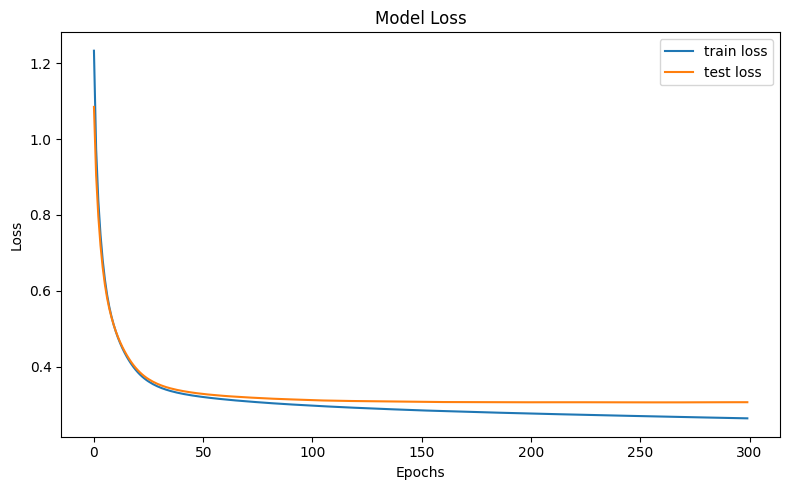

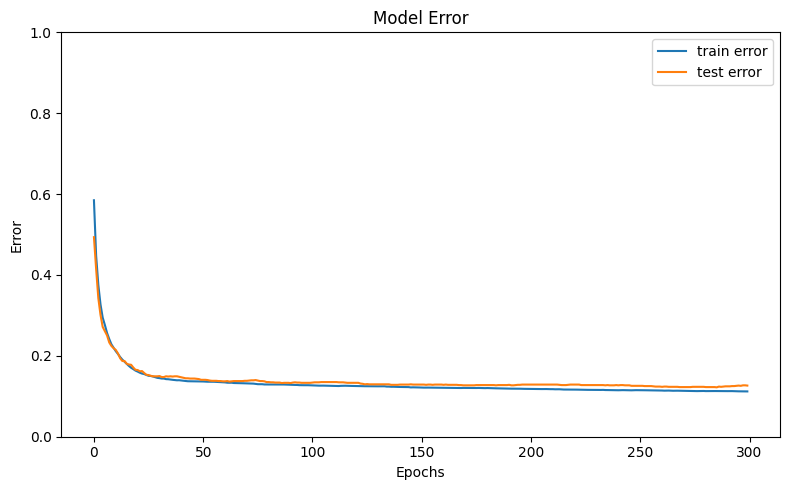

In [99]:
display_results(history_31, start_time_31, end_time_31, IRREDUCIBLE_ERROR)   

# **Paso 32: probamos L1**

In [100]:
REGULARIZER_32 = tf.keras.regularizers.L1(0.0001)

model_32 = tf.keras.Sequential()
model_32.add(tf.keras.layers.InputLayer(shape=(INPUTS,)))
model_32.add(tf.keras.layers.Dense(64, activation="relu", kernel_regularizer=REGULARIZER_32))
model_32.add(tf.keras.layers.Dense(64, activation="relu", kernel_regularizer=REGULARIZER_32))
model_32.add(tf.keras.layers.Dense(OUTPUTS, activation="softmax"))

model_32.compile(
    loss="categorical_crossentropy",
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    metrics=["categorical_accuracy"]
)

In [101]:
start_time_32 = time.perf_counter()
 
history_32 = model_32.fit(
    x_train, t_train,
    epochs=300,
    batch_size=32,
    verbose=0,
    validation_data=(x_dev, t_dev)
)
 
end_time_32 = time.perf_counter()

Error training:  11.7 %
Error development test:  11.8 %
Error bias:  1.7 %
Error variance:  0.2 %
Time:  139 seconds
Accuracy training:     88.3 %
Accuracy dev test:     88.2 %


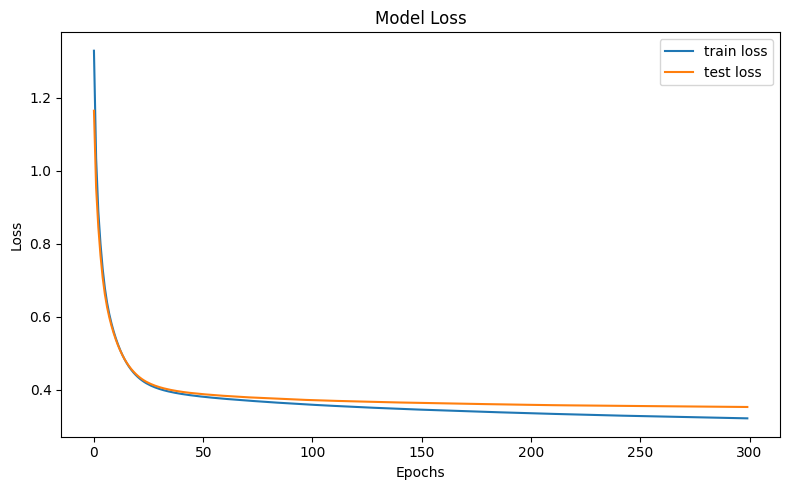

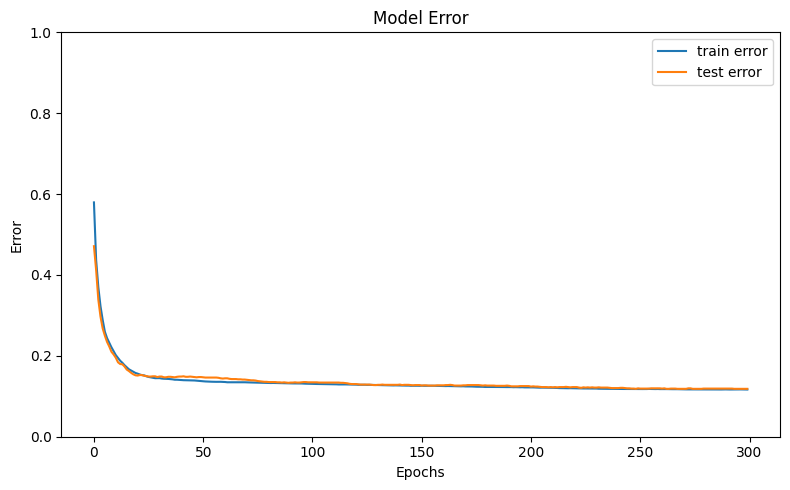

In [102]:
display_results(history_32, start_time_32, end_time_32, IRREDUCIBLE_ERROR)   

## Paso 33: Aumentamos batch size

In [103]:
early_stop_33 = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=25, restore_best_weights=True)

model_33 = tf.keras.Sequential()
model_33.add(tf.keras.layers.InputLayer(shape=(INPUTS,)))
model_33.add(tf.keras.layers.Dense(128, activation="relu"))
model_33.add(tf.keras.layers.Dropout(0.1))
model_33.add(tf.keras.layers.Dense(64, activation="relu"))
model_33.add(tf.keras.layers.Dense(32, activation="relu"))
model_33.add(tf.keras.layers.Dense(OUTPUTS, activation="softmax"))

model_33.compile(
    loss="categorical_crossentropy",
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    metrics=["categorical_accuracy"]
)


In [104]:
start_time_33 = time.perf_counter()

history_33 = model_33.fit(
    x_train, t_train,
    batch_size=1024,
    epochs=500,
    verbose=0,
    validation_data=(x_dev, t_dev),
    callbacks=[early_stop_33]
)

end_time_33 = time.perf_counter()

print("Epochs ejecutados:", len(history_33.history["loss"]))

2026-03-24 20:07:03.206131: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-24 20:07:04.964769: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_703', 304 bytes spill stores, 304 bytes spill loads

2026-03-24 20:07:07.136323: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-24 20:07:07.136359: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were f

Epochs ejecutados: 117


Error training:  11.9 %
Error development test:  12.6 %
Error bias:  1.9 %
Error variance:  0.7 %
Time:  19 seconds
Accuracy training:     88.1 %
Accuracy dev test:     87.4 %


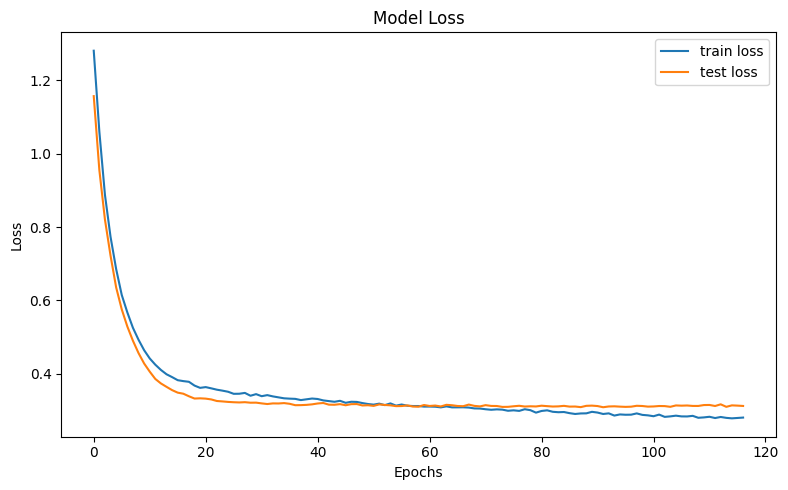

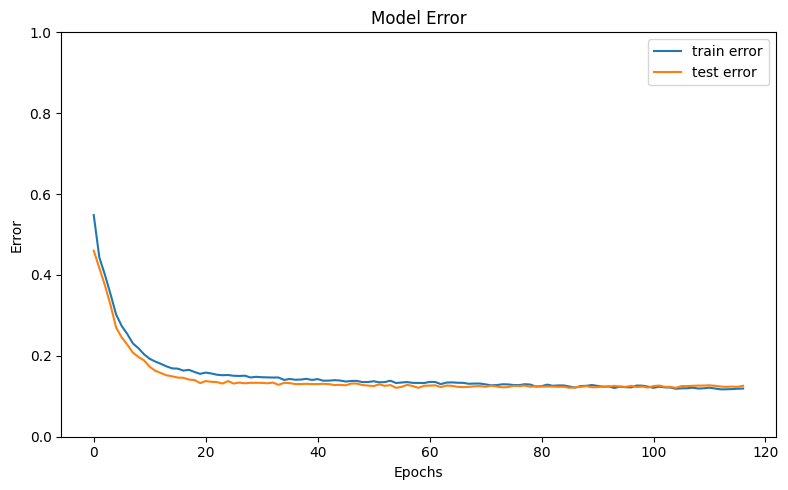

In [105]:
display_results(history_33, start_time_33, end_time_33, IRREDUCIBLE_ERROR)

## Paso 34: Seguimos por aquí aumentando el número de neuronas

In [106]:
early_stop_34 = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=25, restore_best_weights=True)

model_34 = tf.keras.Sequential()
model_34.add(tf.keras.layers.InputLayer(shape=(INPUTS,)))
model_34.add(tf.keras.layers.Dense(256, activation="relu"))
model_34.add(tf.keras.layers.Dropout(0.1))
model_34.add(tf.keras.layers.Dense(128, activation="relu"))
model_34.add(tf.keras.layers.Dropout(0.1))
model_34.add(tf.keras.layers.Dense(64, activation="relu"))
model_34.add(tf.keras.layers.Dense(OUTPUTS, activation="softmax"))

model_34.compile(
    loss="categorical_crossentropy",
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    metrics=["categorical_accuracy"]
)




In [107]:
start_time_34 = time.perf_counter()

history_34 = model_34.fit(
    x_train, t_train,
    batch_size=1024,
    epochs=500,
    verbose=0,
    validation_data=(x_dev, t_dev),
    callbacks=[early_stop_34]
)

end_time_34 = time.perf_counter()

print("Epochs ejecutados:", len(history_34.history["loss"]))

2026-03-24 20:07:24.673912: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1128', 264 bytes spill stores, 264 bytes spill loads

2026-03-24 20:07:24.976240: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1110', 1048 bytes spill stores, 1048 bytes spill loads

2026-03-24 20:07:25.546136: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1110', 10748 bytes spill stores, 11120 bytes spill loads

2026-03-24 20:07:28.649577: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1128', 176 bytes spill stores, 176 bytes spill loads

2026-03-24 20:07:32.233575

Epochs ejecutados: 65


Error training:  11.5 %
Error development test:  12.7 %
Error bias:  1.5 %
Error variance:  1.2 %
Time:  16 seconds
Accuracy training:     88.5 %
Accuracy dev test:     87.3 %


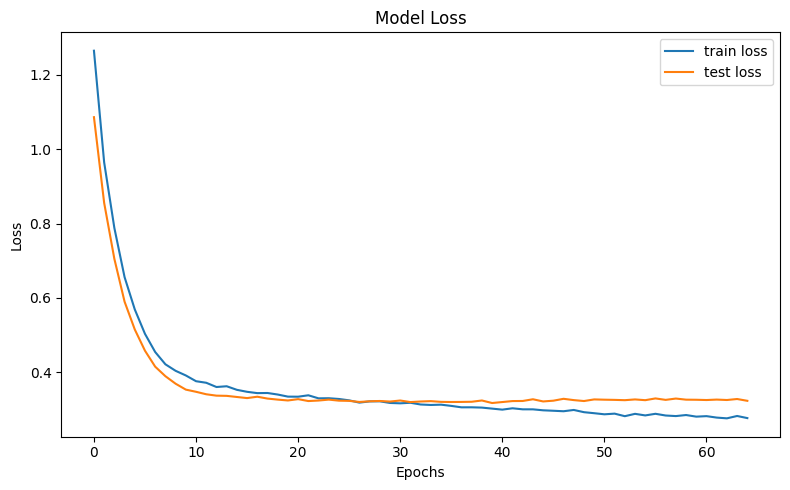

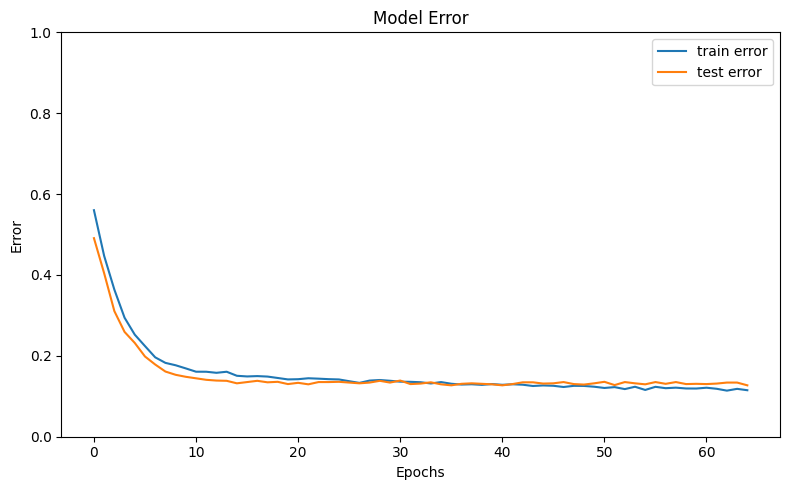

In [108]:
display_results(history_34, start_time_34, end_time_34, IRREDUCIBLE_ERROR)

## Paso 35: con drpout 0.1 y menos neuronas 

In [109]:
early_stop_35 = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=25, restore_best_weights=True)

REGULARIZER_35 = tf.keras.regularizers.L2(0.0001)

model_35 = tf.keras.Sequential()
model_35.add(tf.keras.layers.InputLayer(shape=(INPUTS,)))
model_35.add(tf.keras.layers.Dense(128, activation="relu", kernel_regularizer=REGULARIZER_35))
model_35.add(tf.keras.layers.Dropout(0.1))
model_35.add(tf.keras.layers.Dense(64, activation="relu", kernel_regularizer=REGULARIZER_35))
model_35.add(tf.keras.layers.Dense(OUTPUTS, activation="softmax"))

model_35.compile(
    loss="categorical_crossentropy",
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    metrics=["categorical_accuracy"]
)




In [110]:
start_time_35 = time.perf_counter()

history_35 = model_35.fit(
    x_train, t_train,
    batch_size=1024,
    epochs=500,
    verbose=0,
    validation_data=(x_dev, t_dev),
    callbacks=[early_stop_35]
)

end_time_35 = time.perf_counter()

print("Epochs ejecutados:", len(history_35.history["loss"]))

Epochs ejecutados: 180


Error training:  12.2 %
Error development test:  12.6 %
Error bias:  2.2 %
Error variance:  0.4 %
Time:  20 seconds
Accuracy training:     87.8 %
Accuracy dev test:     87.4 %


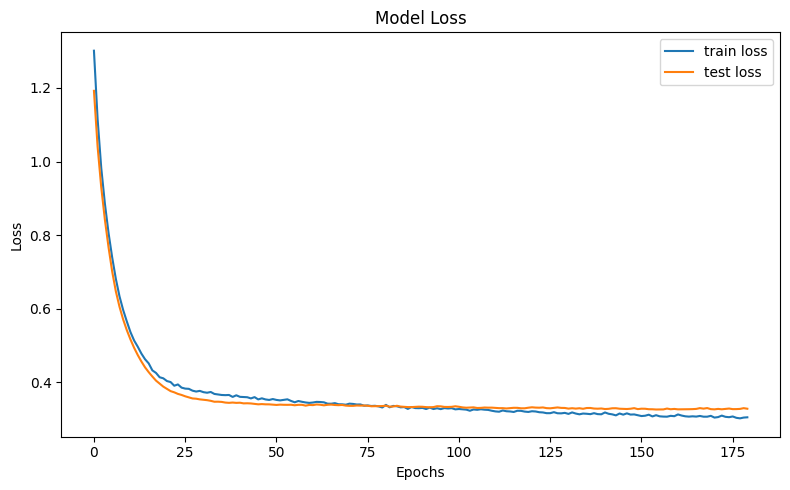

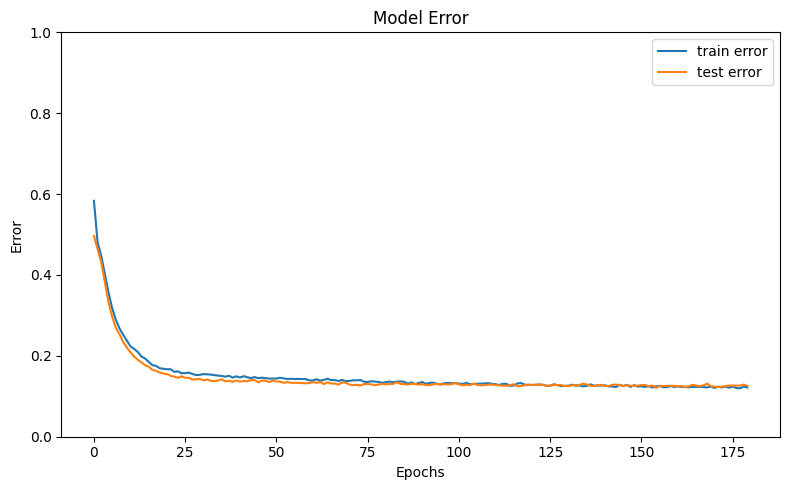

In [111]:
display_results(history_35, start_time_35, end_time_35, IRREDUCIBLE_ERROR)

## Paso 36: Volvemos sin regularizacion y reducimos batch size

In [112]:
early_stop_36 = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=25, restore_best_weights=True)

model_36 = tf.keras.Sequential()
model_36.add(tf.keras.layers.InputLayer(shape=(INPUTS,)))
model_36.add(tf.keras.layers.Dense(128, activation="relu"))
model_36.add(tf.keras.layers.Dropout(0.1))
model_36.add(tf.keras.layers.Dense(64, activation="relu"))
model_36.add(tf.keras.layers.Dense(32, activation="relu"))
model_36.add(tf.keras.layers.Dense(OUTPUTS, activation="softmax"))

model_36.compile(
    loss="categorical_crossentropy",
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    metrics=["categorical_accuracy"]
)



In [113]:

start_time_36 = time.perf_counter()

history_36 = model_36.fit(
    x_train, t_train,
    batch_size=512,
    epochs=500,
    verbose=0,
    validation_data=(x_dev, t_dev),
    callbacks=[early_stop_36]
)

end_time_36 = time.perf_counter()

print("Epochs ejecutados:", len(history_36.history["loss"]))

2026-03-24 20:07:59.082798: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-24 20:07:59.082832: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-24 20:08:00.314677: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_715', 124 bytes spill stores, 124 bytes spill loads

2026-03-24 20:08:00.448605: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning 

Epochs ejecutados: 84


Error training:  12.4 %
Error development test:  12.3 %
Error bias:  2.4 %
Error variance:  -0.1 %
Time:  20 seconds
Accuracy training:     87.6 %
Accuracy dev test:     87.7 %


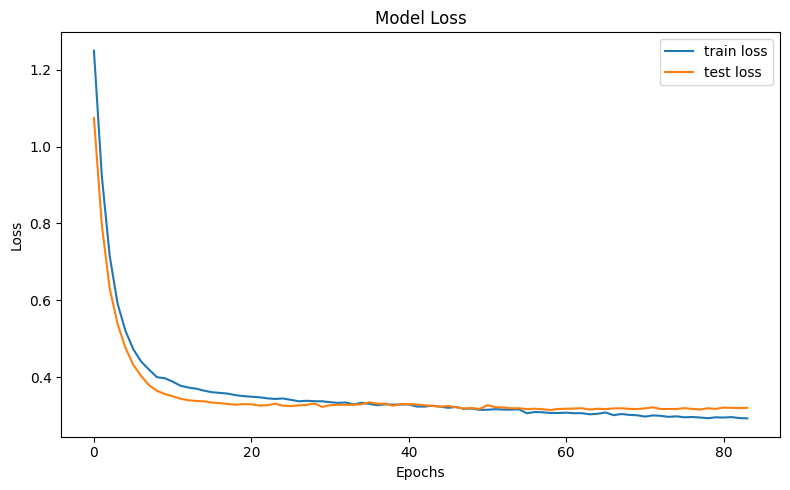

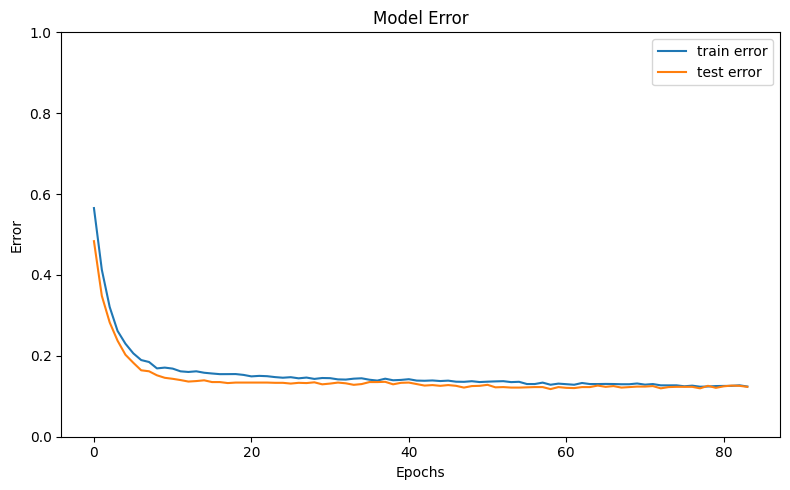

In [114]:
display_results(history_36, start_time_36, end_time_36, IRREDUCIBLE_ERROR)

## Paso 37: aumentamos capas ocultas

In [115]:
early_stop_37 = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=25, restore_best_weights=True)

model_37 = tf.keras.Sequential()
model_37.add(tf.keras.layers.InputLayer(shape=(INPUTS,)))
model_37.add(tf.keras.layers.Dense(500, activation="relu"))
model_37.add(tf.keras.layers.Dense(250, activation="relu"))
model_37.add(tf.keras.layers.Dense(125, activation="relu"))
model_37.add(tf.keras.layers.Dense(64, activation="relu"))
model_37.add(tf.keras.layers.Dense(OUTPUTS, activation="softmax"))

model_37.compile(
    loss="categorical_crossentropy",
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    metrics=["categorical_accuracy"]
)




In [116]:
start_time_37 = time.perf_counter()

history_37 = model_37.fit(
    x_train, t_train,
    batch_size=1024,
    epochs=600,
    verbose=0,
    validation_data=(x_dev, t_dev),
    callbacks=[early_stop_37]
)

end_time_37 = time.perf_counter()

print("Epochs ejecutados:", len(history_37.history["loss"]))

2026-03-24 20:08:20.049408: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_415', 12 bytes spill stores, 12 bytes spill loads

2026-03-24 20:08:20.688824: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_433', 8 bytes spill stores, 8 bytes spill loads

2026-03-24 20:08:21.908684: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_403', 528 bytes spill stores, 396 bytes spill loads

2026-03-24 20:08:22.146511: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_429', 1828 bytes spill stores, 1828 bytes spill loads

2026-03-24 20:08:22.735508: I external/l

Epochs ejecutados: 42


Error training:  8.8 %
Error development test:  13.6 %
Error bias:  -1.2 %
Error variance:  4.8 %
Time:  18 seconds
Accuracy training:     91.2 %
Accuracy dev test:     86.4 %


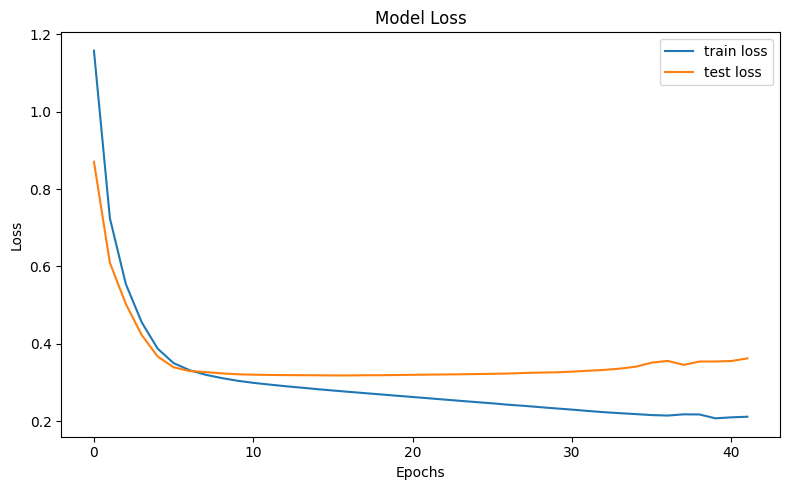

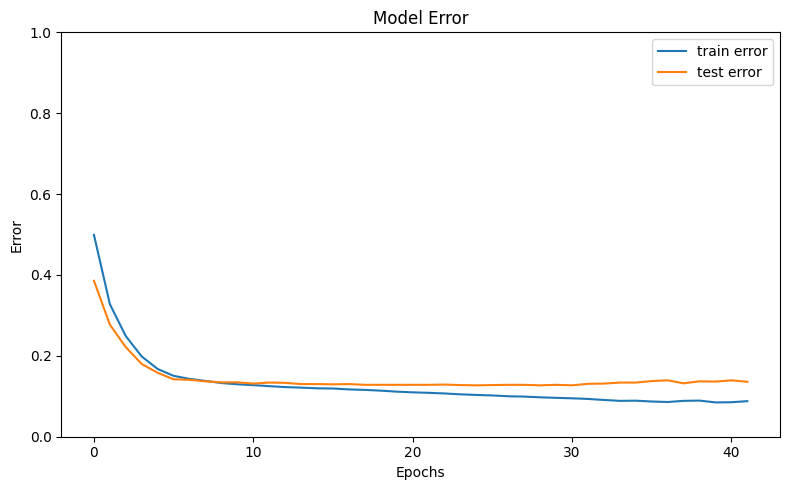

In [117]:
display_results(history_37, start_time_37, end_time_37, IRREDUCIBLE_ERROR)

In [118]:
best_accuracy = 0
best_history = None

for i in range(5):
    early_stop_37 = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=25)
    
    model_37 = tf.keras.Sequential()
    model_37.add(tf.keras.layers.InputLayer(shape=(INPUTS,)))
    model_37.add(tf.keras.layers.Dense(128, activation="relu"))
    model_37.add(tf.keras.layers.Dropout(0.1))
    model_37.add(tf.keras.layers.Dense(64, activation="relu"))
    model_37.add(tf.keras.layers.Dense(32, activation="relu"))
    model_37.add(tf.keras.layers.Dense(OUTPUTS, activation="softmax"))
    
    model_37.compile(
        loss="categorical_crossentropy",
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        metrics=["categorical_accuracy"]
    )
    
    history_37 = model_37.fit(
        x_train, t_train,
        batch_size=1024,
        epochs=500,
        verbose=0,
        validation_data=(x_dev, t_dev),
        callbacks=[early_stop_37]
    )
    
    acc = history_37.history["val_categorical_accuracy"][-1]
    print(f"Run {i+1}: dev accuracy = {round(acc*100, 1)}%")
    
    if acc > best_accuracy:
        best_accuracy = acc
        best_history = history_37
        best_model = model_37

print(f"\nMejor dev accuracy: {round(best_accuracy*100, 1)}%")

Run 1: dev accuracy = 87.7%
Run 2: dev accuracy = 87.5%
Run 3: dev accuracy = 87.0%
Run 4: dev accuracy = 87.5%
Run 5: dev accuracy = 87.0%

Mejor dev accuracy: 87.7%


## Evaluación final en test set (modelo Paso 32)

In [125]:
# Evaluación fija sobre el modelo del Paso 32
selected_model = model_32

# Métrica de dev del Paso 32 (última época)
dev_accuracy_32 = history_32.history["val_categorical_accuracy"][-1]
print("=== Modelo seleccionado ===")
print("Paso: 32")
print(f"Dev Accuracy (última época): {dev_accuracy_32*100:.2f}%")

test_loss_best, test_accuracy_best = selected_model.evaluate(x_test, t_test, verbose=0)
print("\n=== Evaluación en TEST SET (modelo Paso 32) ===")
print(f"Test Loss: {test_loss_best:.4f}")
print(f"Test Accuracy: {test_accuracy_best*100:.2f}%")
print(f"Test Error: {(1-test_accuracy_best)*100:.2f}%")

=== Modelo seleccionado ===
Paso: 32
Dev Accuracy (última época): 88.16%

=== Evaluación en TEST SET (modelo Paso 32) ===
Test Loss: 0.3647
Test Accuracy: 86.74%
Test Error: 13.26%


=== Classification Report (TEST) ===
              precision    recall  f1-score   support

        Poor      0.942     0.916     0.929       427
Intermediate      0.797     0.814     0.806       392
        Good      0.807     0.855     0.830       441
   Excellent      0.943     0.884     0.913       354

    accuracy                          0.867      1614
   macro avg      0.872     0.867     0.869      1614
weighted avg      0.870     0.867     0.868      1614



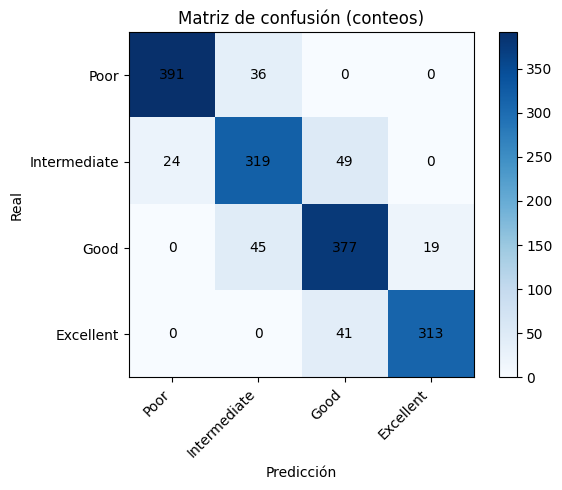

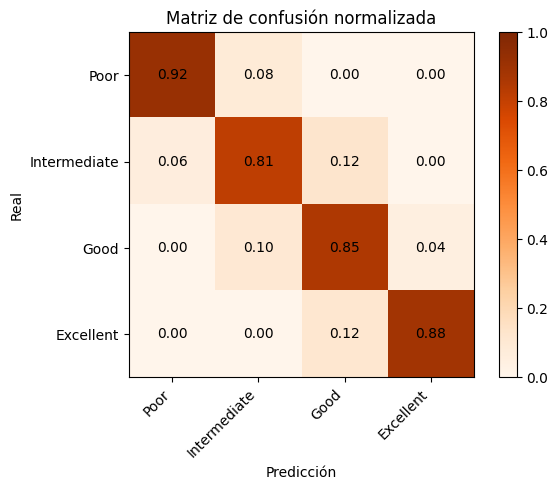

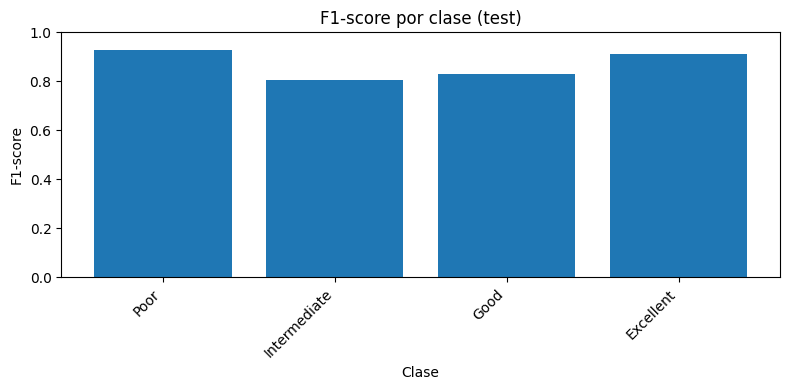

=== Top confusiones (real -> predicha) ===
Intermediate -> Good: 49
Good -> Intermediate: 45
Excellent -> Good: 41
Poor -> Intermediate: 36
Intermediate -> Poor: 24
Good -> Excellent: 19


In [124]:
from sklearn.metrics import classification_report, confusion_matrix

# Nombres simples de clase (sin intervalos ni texto adicional)
if t_test.shape[1] == 4:
    class_names = ["Poor", "Intermediate", "Good", "Excellent"]
else:
    class_names = [f"Clase {i+1}" for i in range(t_test.shape[1])]

y_proba_test = selected_model.predict(x_test, verbose=0)
y_pred_test = np.argmax(y_proba_test, axis=1)
y_true_test = np.argmax(t_test, axis=1)

print("=== Classification Report (TEST) ===")
print(classification_report(y_true_test, y_pred_test, target_names=class_names, digits=3))

cm = confusion_matrix(y_true_test, y_pred_test)
cm_norm = confusion_matrix(y_true_test, y_pred_test, normalize="true")

# Gráfica 1: matriz de confusión (conteos)
plt.figure(figsize=(7, 5))
ax = plt.gca()
im0 = ax.imshow(cm, cmap="Blues")
ax.set_title("Matriz de confusión (conteos)")
ax.set_xlabel("Predicción")
ax.set_ylabel("Real")
ax.set_xticks(range(len(class_names)))
ax.set_yticks(range(len(class_names)))
ax.set_xticklabels(class_names, rotation=45, ha="right")
ax.set_yticklabels(class_names)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center", color="black")
plt.colorbar(im0, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

# Gráfica 2: matriz de confusión normalizada
plt.figure(figsize=(7, 5))
ax = plt.gca()
im1 = ax.imshow(cm_norm, cmap="Oranges", vmin=0, vmax=1)
ax.set_title("Matriz de confusión normalizada")
ax.set_xlabel("Predicción")
ax.set_ylabel("Real")
ax.set_xticks(range(len(class_names)))
ax.set_yticks(range(len(class_names)))
ax.set_xticklabels(class_names, rotation=45, ha="right")
ax.set_yticklabels(class_names)
for i in range(cm_norm.shape[0]):
    for j in range(cm_norm.shape[1]):
        ax.text(j, i, f"{cm_norm[i, j]:.2f}", ha="center", va="center", color="black")
plt.colorbar(im1, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

# Gráfica 3: F1-score por clase
report_dict = classification_report(
    y_true_test,
    y_pred_test,
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

f1_scores = [report_dict[c]["f1-score"] for c in class_names]

plt.figure(figsize=(8, 4))
plt.bar(class_names, f1_scores)
plt.ylim(0, 1)
plt.title("F1-score por clase (test)")
plt.ylabel("F1-score")
plt.xlabel("Clase")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Extra: pares de confusión más frecuentes (errores más comunes)
errors = []
for i, real_name in enumerate(class_names):
    for j, pred_name in enumerate(class_names):
        if i != j and cm[i, j] > 0:
            errors.append((cm[i, j], real_name, pred_name))

errors.sort(reverse=True)
print("=== Top confusiones (real -> predicha) ===")
if len(errors) == 0:
    print("No hay errores de clasificación en test set.")
else:
    for count, real_name, pred_name in errors[:10]:
        print(f"{real_name} -> {pred_name}: {count}")